# Ζ Proyecto Zeta | Análisis del Mercado Global de Videojuegos

## Contexto empresarial

Ice es una tienda en línea dedicada a la venta de videojuegos en distintos mercados internacionales. La compañía dispone de información histórica sobre ventas, plataformas, géneros, reseñas de usuarios y críticos profesionales, así como clasificaciones ESRB asociadas a cada juego.

El objetivo de este proyecto es identificar los factores que caracterizan a los videojuegos exitosos y determinar qué patrones pueden utilizarse para anticipar tendencias de mercado. Esta información permitirá apoyar la planificación de campañas publicitarias y orientar decisiones comerciales para el año 2017.

## Objetivos

- Evaluar la calidad y consistencia de los datos disponibles.
- Analizar la evolución de la industria de videojuegos a través del tiempo.
- Identificar las plataformas con mejor desempeño comercial.
- Estudiar el ciclo de vida de las principales plataformas.
- Analizar la relación entre las reseñas y las ventas de los videojuegos.
- Identificar los géneros con mayor potencial comercial.
- Construir perfiles de consumo para diferentes regiones del mundo.
- Evaluar el impacto de las clasificaciones ESRB en las ventas.
- Validar hipótesis mediante pruebas estadísticas.
- Generar recomendaciones para apoyar futuras campañas de marketing.

## Conjuntos de datos utilizados

- `games.csv`

## Variables principales

- `name`
- `platform`
- `year_of_release`
- `genre`
- `na_sales`
- `eu_sales`
- `jp_sales`
- `other_sales`
- `critic_score`
- `user_score`
- `rating`

## Pregunta de negocio

**¿Qué características tienen los videojuegos más exitosos y cuáles son las plataformas, géneros y mercados más prometedores para orientar la estrategia comercial de Ice durante 2017?**

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns

Primero leemos nuestro archivo de trabajo

In [ ]:
games = pd.read_csv("/content/games.csv")

In [ ]:
games.columns = games.columns.str.lower()


Se realizó una revisión general de la base de datos para comprender su estructura, identificar posibles problemas de calidad y preparar la información para el análisis posterior.

El conjunto de datos contiene más de 16 mil videojuegos e incluye información sobre plataformas, géneros, ventas regionales, calificaciones de usuarios, puntuaciones de críticos y clasificaciones ESRB. Esta variedad de variables permitirá analizar múltiples factores asociados al éxito comercial de los videojuegos.

In [ ]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Búsqueda de valores ausentes

Los resultados muestran que las ventas regionales no presentan datos ausentes, lo que garantiza la disponibilidad de la información necesaria para estudiar el desempeño comercial de los videojuegos. Sin embargo, se identificaron valores faltantes en variables relacionadas con las características de los juegos, las evaluaciones de usuarios y las clasificaciones de contenido.

In [ ]:
games.isna().sum()

,0
name,2
platform,0
year_of_release,269
genre,2
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0
critic_score,8578
user_score,6701


Durante la revisión de los valores ausentes se identificaron dos registros sin información en la columna `name`. Debido a que la cantidad de casos representa una proporción mínima dentro del conjunto de datos, se optó por reemplazar los valores faltantes por la etiqueta **"no ingresó nombre"**.

In [ ]:
games["name"] = games["name"].fillna("no ingresó nombre")

In [ ]:
print(games["name"][games["name"] == "no ingresó nombre"])

659      no ingresó nombre
14244    no ingresó nombre
Name: name, dtype: object


Durante la exploración de los datos se identificaron registros sin información en la variable `year_of_release`. Dado que el año de lanzamiento es una característica importante para los análisis temporales del proyecto, fue necesario aplicar un tratamiento a estos valores faltantes.

In [ ]:
games["year_of_release"] = games["year_of_release"].fillna(0)

In [ ]:
print(games["year_of_release"].isna().sum())

0


In [ ]:
print(games["year_of_release"][games["year_of_release"] == 0])

183      0.0
377      0.0
456      0.0
475      0.0
609      0.0
        ... 
16373    0.0
16405    0.0
16448    0.0
16458    0.0
16522    0.0
Name: year_of_release, Length: 269, dtype: float64


In [ ]:
games["genre"] = games["genre"].fillna("genero desconocido")

In [ ]:
print(games["genre"][games["genre"] =="genero desconocido"])

659      genero desconocido
14244    genero desconocido
Name: genre, dtype: object


In [ ]:
print(games["user_score"].isna().sum())

6701


In [ ]:
print(games["rating"].isna().sum())

6766


In [ ]:
games["rating"] = games["rating"].fillna(0)

Búsqueda de valores duplicados explícitos

In [ ]:
print(games.duplicated().sum())

0


Búsqueda de duplicados implícitos

In [ ]:
pd.unique(games.values.ravel())

array(['Wii Sports', 'Wii', 2006.0, ...,
       'Woody Woodpecker in Crazy Castle 5', 'LMA Manager 2007',
       'Haitaka no Psychedelica'], dtype=object)

Calculo de ventas totales

In [ ]:
print(games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           16715 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


Análisis de datos

Observación de cuántos juegos fueron lanzados en diferentes años

In [ ]:
print(games["year_of_release"].value_counts())

year_of_release
2008.0    1427
2009.0    1426
2010.0    1255
2007.0    1197
2011.0    1136
2006.0    1006
2005.0     939
2002.0     829
2003.0     775
2004.0     762
2012.0     653
2015.0     606
2014.0     581
2013.0     544
2016.0     502
2001.0     482
1998.0     379
2000.0     350
1999.0     338
1997.0     289
0.0        269
1996.0     263
1995.0     219
1994.0     121
1993.0      62
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1983.0      17
1989.0      17
1987.0      16
1990.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
Name: count, dtype: int64


Observación de plataformas con las mayores ventas totales

In [ ]:
print(games["platform"].value_counts())

platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64


Calculo de ventas totales por juego

In [ ]:
games["total_sales"] = (games["na_sales"] + games["eu_sales"] + games["jp_sales"] + games["other_sales"])

Eliminación de años invalidos

In [ ]:
games = games[games["year_of_release"] > 0].copy()

Conversión de años decimales a enteros

In [ ]:
games["year_of_release"] = games["year_of_release"].astype(int)

Confirmación de conversión exitosa de años decimales a enteros

In [ ]:
print(games["year_of_release"].sort_values().unique())

[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016]


Conversión de la columna user_score a columna numérica

In [ ]:
games["user_score"] = pd.to_numeric(games["user_score"], errors = "coerce")


Confirmación de conversión exitosa de la columna user_score a numérica

In [ ]:
print(games["user_score"].dtype)

float64


Verificación del estado general del dataset después de la limpieza

In [ ]:
games.info()
print(games.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16446 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16446 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16446 non-null  object 
 11  total_sales      16446 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB
                        name platform  year_of_release         genre  \
0                 Wii Sports      Wii             2006        Sports   
1          Super Mario Bros.      NES         

generacion de una tabla que detalle ventas por año

In [ ]:
ventas_por_año = (games.groupby("year_of_release")["total_sales"].sum().reset_index())

Impresión de la tabla temporal generada

In [ ]:
print(ventas_por_año)

    year_of_release  total_sales
0              1980        11.38
1              1981        35.68
2              1982        28.88
3              1983        16.80
4              1984        50.35
5              1985        53.95
6              1986        37.08
7              1987        21.70
8              1988        47.21
9              1989        73.45
10             1990        49.37
11             1991        32.23
12             1992        76.16
13             1993        48.41
14             1994        79.23
15             1995        88.12
16             1996       199.15
17             1997       201.07
18             1998       256.31
19             1999       251.11
20             2000       201.66
21             2001       331.46
22             2002       394.97
23             2003       357.54
24             2004       418.68
25             2005       457.82
26             2006       517.71
27             2007       604.75
28             2008       671.50
29        

Creación del espacio en blanco de la gráfica que se construirá después

In [ ]:
plt.figure(figsize = (90, 6))

<Figure size 9000x600 with 0 Axes>

<Figure size 9000x600 with 0 Axes>

Construcción de una grafica de líneas (evolución temporal)

## Evolución de las ventas globales de videojuegos por año de lanzamiento

El análisis de las ventas globales por año revela una clara evolución del mercado de videojuegos a lo largo del tiempo. Durante la década de 1980 y principios de los años 90, las ventas se mantuvieron en niveles relativamente bajos, reflejando una industria todavía en proceso de expansión.

<Axes: xlabel='year_of_release', ylabel='total_sales'>

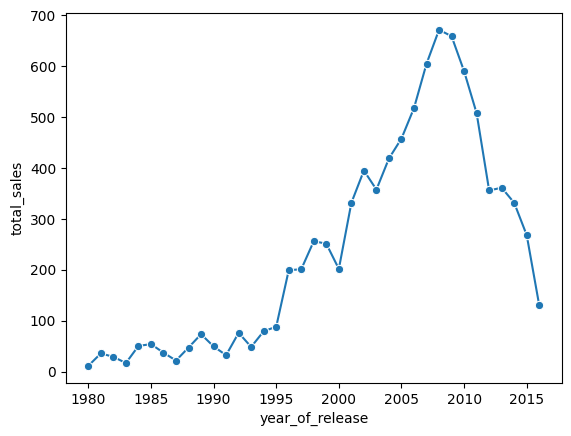

In [ ]:
sns.lineplot(data = ventas_por_año, x = "year_of_release", y = "total_sales", marker = "o")

Generación de títulos para el la gráfica general, el eje x, y el eje y

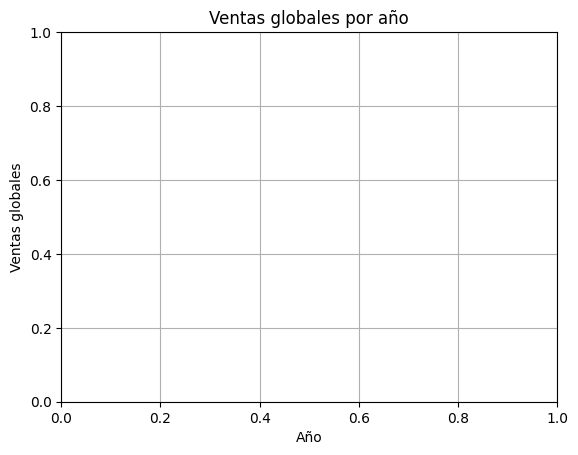

In [ ]:
plt.title("Ventas globales por año")
plt.xlabel("Año")
plt.ylabel("Ventas globales")
plt.grid(True)

Muestra de la gráfica final

In [ ]:
plt.show()

Combinación de estos pasos para la construcción de la grafica final

## Evolución de las ventas globales de videojuegos por año de lanzamiento

El análisis de las ventas globales muestra una evolución clara de la industria de los videojuegos a lo largo de más de tres décadas. Durante los años ochenta y principios de los noventa, el mercado registró niveles de ventas relativamente bajos y un crecimiento moderado, característico de una industria que aún se encontraba en proceso de expansión.

A partir de 1996 se observa un incremento significativo en las ventas globales, seguido de un período de crecimiento sostenido que se prolonga durante más de una década. Este crecimiento alcanza su punto máximo entre 2008 y 2009, cuando las ventas superan los **650 millones de dólares**, convirtiéndose en el período de mayor actividad comercial dentro del conjunto de datos.

    year_of_release  total_sales
0              1980        11.38
1              1981        35.68
2              1982        28.88
3              1983        16.80
4              1984        50.35
5              1985        53.95
6              1986        37.08
7              1987        21.70
8              1988        47.21
9              1989        73.45
10             1990        49.37
11             1991        32.23
12             1992        76.16
13             1993        48.41
14             1994        79.23
15             1995        88.12
16             1996       199.15
17             1997       201.07
18             1998       256.31
19             1999       251.11
20             2000       201.66
21             2001       331.46
22             2002       394.97
23             2003       357.54
24             2004       418.68
25             2005       457.82
26             2006       517.71
27             2007       604.75
28             2008       671.50
29        

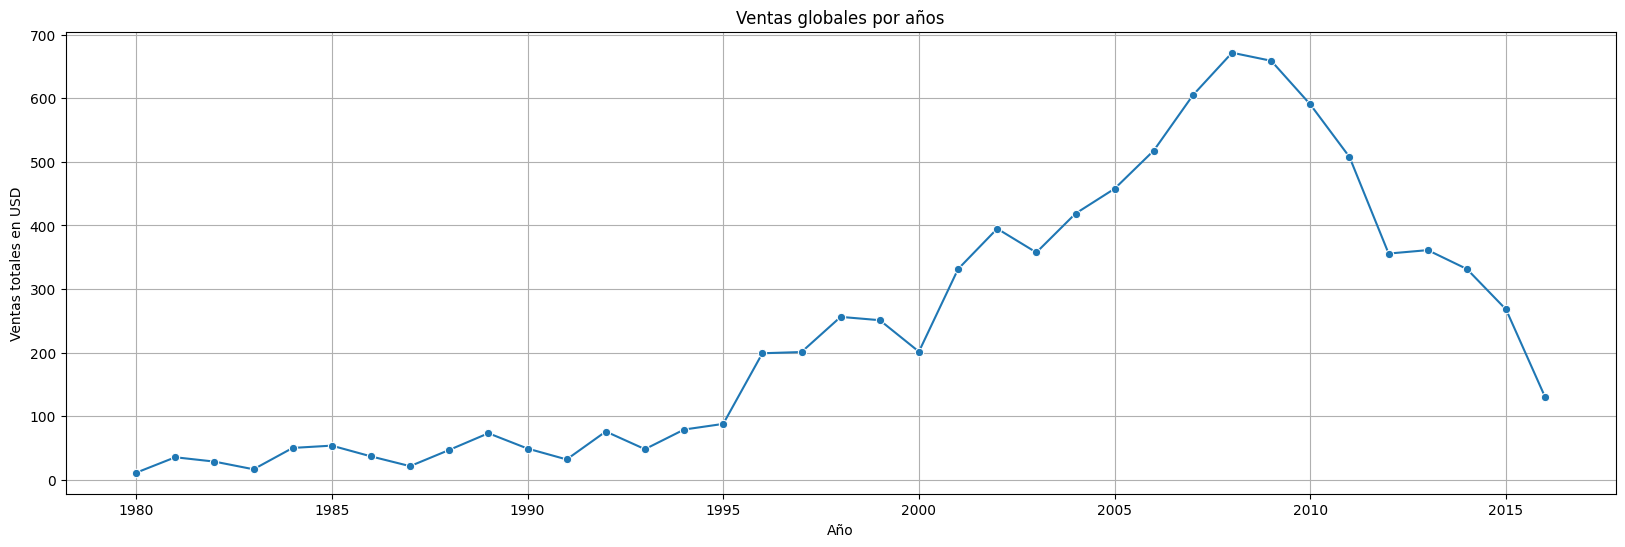

In [ ]:
ventas_por_año = games.groupby("year_of_release")["total_sales"].sum().reset_index().copy()

print(ventas_por_año)

plt.figure(figsize = (20, 6))

sns.lineplot(data = ventas_por_año, x = "year_of_release", y = "total_sales", marker = "o" )

plt.title("Ventas globales por años")
plt.xlabel("Año")
plt.ylabel("Ventas totales en USD")
plt.grid(True)

Generación de un dataframe independiente con los años recientes elegidos desde el 2012 hasta el 2016

In [ ]:
games_relevante = games[games["year_of_release"] >= 2012].copy()

impresión del dataframe independiente

In [ ]:
print(games_relevante)

                                name platform  year_of_release         genre  \
16                Grand Theft Auto V      PS3             2013        Action   
23                Grand Theft Auto V     X360             2013        Action   
31         Call of Duty: Black Ops 3      PS4             2015       Shooter   
33               Pokemon X/Pokemon Y      3DS             2013  Role-Playing   
34        Call of Duty: Black Ops II      PS3             2012       Shooter   
...                              ...      ...              ...           ...   
16703               Strawberry Nauts      PSV             2016     Adventure   
16707               Aiyoku no Eustia      PSV             2014          Misc   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

Busqueda de valores unicos para confirmar presencia solor de los años de interes de forma ordenada ascendente

In [ ]:
print(games_relevante["year_of_release"].sort_values().unique())

[2012 2013 2014 2015 2016]


Verificación del tamaño del nuevo dataset independiente

In [ ]:
print(games_relevante.shape)

(2886, 12)


Generación de dataframe nuevo independiente que detalle las plataformas lideres en ventas

Al analizar únicamente los años más recientes del mercado, se observa que **PlayStation 4 (PS4)** lidera las ventas globales con más de **314 millones de dólares**, seguida por **PlayStation 3 (PS3)** con aproximadamente **289 millones** y **Xbox 360 (X360)** con cerca de **237 millones**.

In [ ]:
ventas_plataforma = games_relevante.groupby("platform")["total_sales"].sum().sort_values(ascending = False).reset_index()

print("Las ventas totales de las plataformas de años recientes son: ")
print()
print(ventas_plataforma)

Las ventas totales de las plataformas de años recientes son: 

   platform  total_sales
0       PS4       314.14
1       PS3       288.79
2      X360       236.54
3       3DS       194.61
4      XOne       159.32
5      WiiU        82.19
6        PC        62.65
7       PSV        49.18
8       Wii        35.37
9        DS        12.55
10      PSP        11.19


Construcción de grafica de barras para ver el las ventas totales por plataformas

El gráfico confirma que unas pocas plataformas concentran la mayor parte de las ventas del mercado durante el período analizado. La plataforma con mejores resultados es **PlayStation 4 (PS4)**, seguida por **PlayStation 3 (PS3)** y **Xbox 360 (X360)**, que dominan claramente el mercado en términos de ventas acumuladas.

Las diferencias entre plataformas son considerables. Mientras PS4 supera los 300 millones de dólares en ventas, plataformas como **DS** y **PSP** registran niveles mucho más reducidos, lo que evidencia distintas etapas dentro de sus ciclos de vida comerciales.

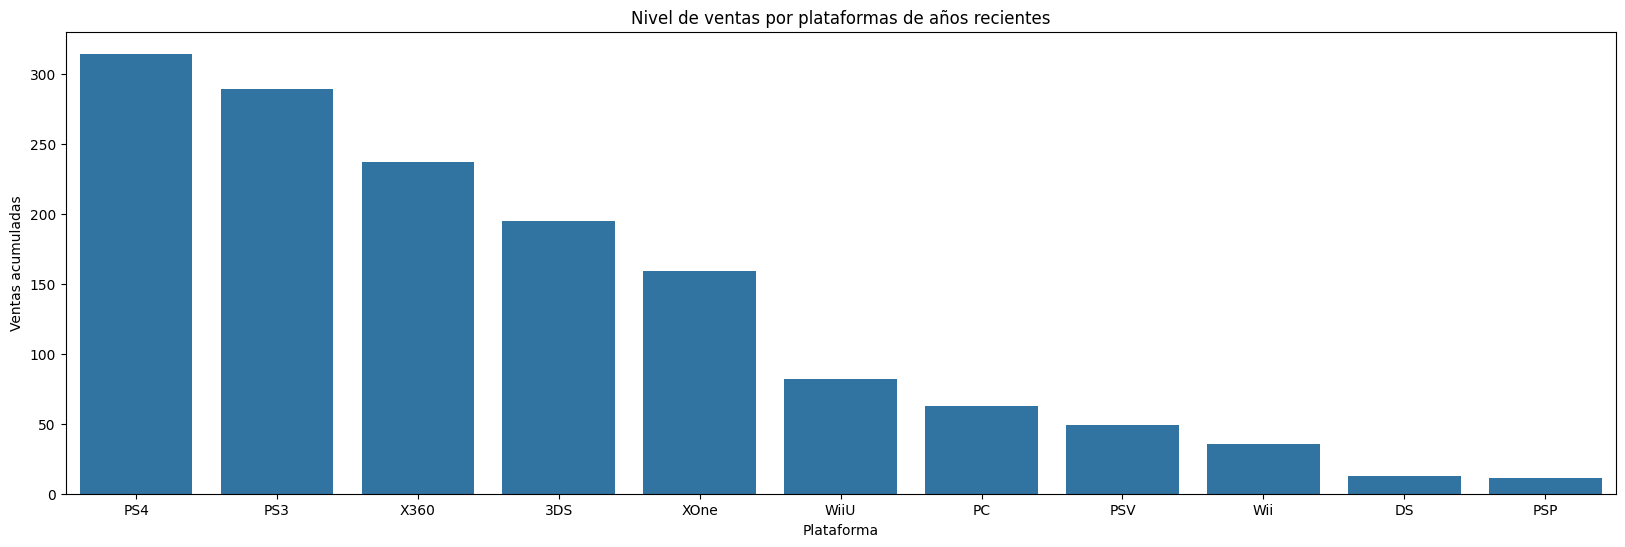

In [ ]:
plt.figure(figsize = (20, 6))

sns.barplot(data = ventas_plataforma, x = "platform", y = "total_sales")

plt.title("Nivel de ventas por plataformas de años recientes")
plt.xlabel("Plataforma")
plt.ylabel("Ventas acumuladas")
plt.show()

Generación de un dataframe con los datos de los años relevantes para detallar las ventas obtenidas por plataformas a lo largo de los años

In [ ]:
ventas_plataforma_años = games_relevante.groupby(["platform", "year_of_release"])["total_sales"].sum().reset_index().sort_values(["platform", "year_of_release"], ascending = False).copy()

print("Las ventas de las plataformas líderes a lo largo de los años son: ")
print()
print(ventas_plataforma_años)

Las ventas de las plataformas líderes a lo largo de los años son: 

   platform  year_of_release  total_sales
48     XOne             2016        26.15
47     XOne             2015        60.14
46     XOne             2014        54.07
45     XOne             2013        18.96
44     X360             2016         1.52
43     X360             2015        11.96
42     X360             2014        34.74
41     X360             2013        88.58
40     X360             2012        99.74
39     WiiU             2016         4.60
38     WiiU             2015        16.35
37     WiiU             2014        22.03
36     WiiU             2013        21.65
35     WiiU             2012        17.56
34      Wii             2016         0.18
33      Wii             2015         1.14
32      Wii             2014         3.75
31      Wii             2013         8.59
30      Wii             2012        21.71
29      PSV             2016         4.25
28      PSV             2015         6.25
27      

Graficación con diagrama de lineas para detallar la evolución temporal

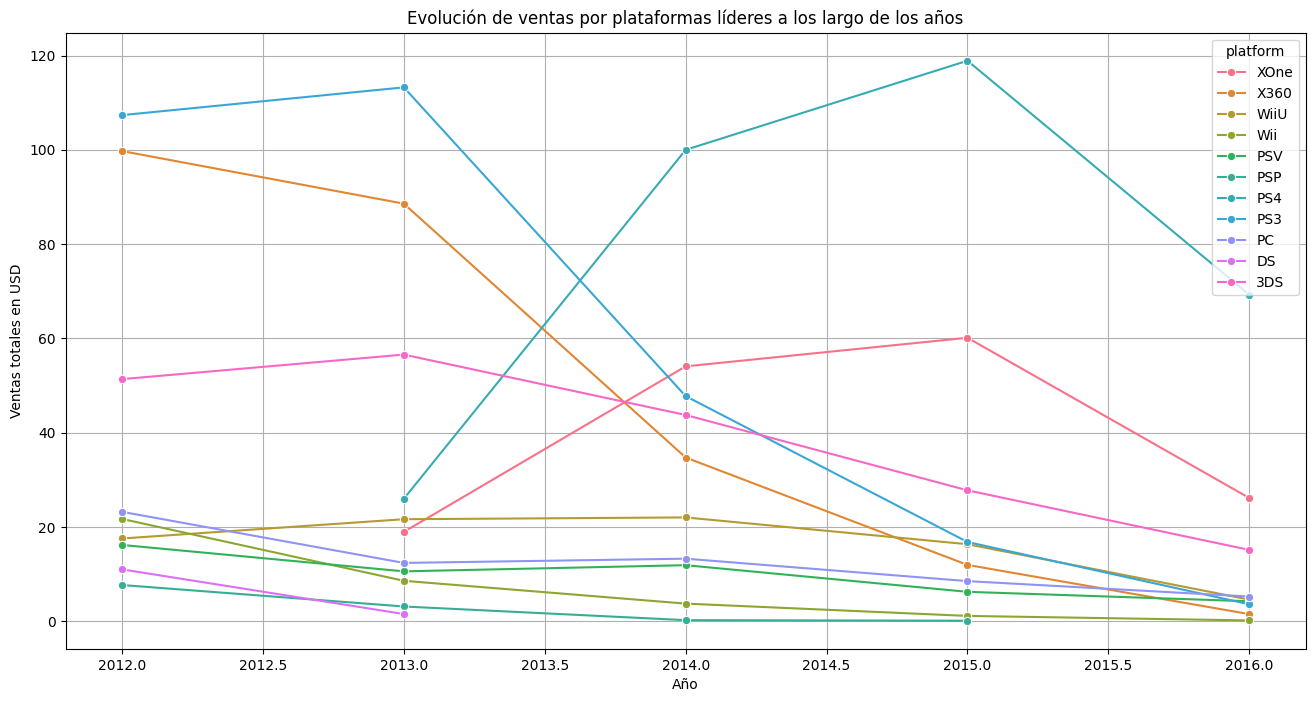

In [ ]:
plt.figure(figsize = (16, 8))

sns.lineplot(data = ventas_plataforma_años, x = "year_of_release", y = "total_sales", hue = "platform", marker = "o")

plt.title("Evolución de ventas por plataformas líderes a los largo de los años")
plt.xlabel("Año")
plt.ylabel("Ventas totales en USD")
plt.grid()
plt.show()


Generación de un dataframe con las 5 plataforma con más ventas en los últimos años

In [ ]:
top_plataformas = ventas_plataforma.head(5)["platform"]

print("Las 10 plataformas con ventas más recientes son:")
print()
print(top_plataformas)

games_top = games_relevante[games_relevante["platform"].isin(top_plataformas)].copy()

Las 10 plataformas con ventas más recientes son:

0     PS4
1     PS3
2    X360
3     3DS
4    XOne
Name: platform, dtype: object


Construcción de una gráfica de líneas con las 5 mejores plataformas

## Evolución de las plataformas con mayores ventas

Para identificar las plataformas con mejor potencial comercial hacia 2017, se analizó la evolución anual de las cinco plataformas con mayores ventas acumuladas durante el período reciente: **PS4, PS3, Xbox 360, Xbox One y Nintendo 3DS**.

El gráfico muestra una clara transición entre generaciones de consolas. Las plataformas **PS3** y **Xbox 360**, que lideraban el mercado en 2012 y 2013, experimentan una disminución constante de sus ventas a partir de 2014. Esta tendencia indica que ambas plataformas se encuentran en la etapa final de su ciclo de vida y están siendo reemplazadas progresivamente por nuevas generaciones.

En contraste, **PS4** registra un crecimiento muy acelerado desde su lanzamiento en 2013. Sus ventas aumentan de aproximadamente 26 millones de dólares en 2013 a casi 119 millones en 2015, convirtiéndose en la plataforma dominante del mercado. Aunque en 2016 se observa una disminución, continúa siendo la plataforma con mayor volumen de ventas.

In [ ]:
ventas_top_año = games_top.groupby(["platform", "year_of_release"])["total_sales"].sum().reset_index().sort_values(["platform", "year_of_release"])


print("Ventas por año de las plataformas principales:")
print()
print(ventas_top_año)


Ventas por año de las plataformas principales:

   platform  year_of_release  total_sales
0       3DS             2012        51.36
1       3DS             2013        56.57
2       3DS             2014        43.76
3       3DS             2015        27.78
4       3DS             2016        15.14
5       PS3             2012       107.36
6       PS3             2013       113.25
7       PS3             2014        47.76
8       PS3             2015        16.82
9       PS3             2016         3.60
10      PS4             2013        25.99
11      PS4             2014       100.00
12      PS4             2015       118.90
13      PS4             2016        69.25
14     X360             2012        99.74
15     X360             2013        88.58
16     X360             2014        34.74
17     X360             2015        11.96
18     X360             2016         1.52
19     XOne             2013        18.96
20     XOne             2014        54.07
21     XOne             2015

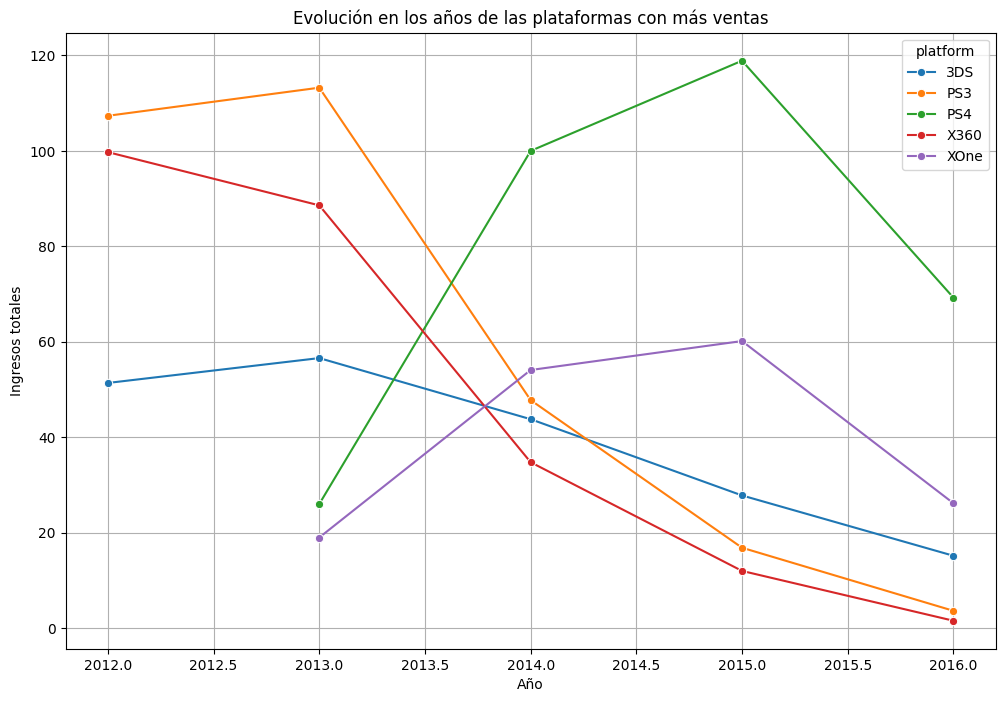

In [ ]:
plt.figure(figsize = (12, 8))

sns.lineplot(data = ventas_top_año, x = "year_of_release", y = "total_sales", hue = "platform", marker = "o")

plt.title("Evolución en los años de las plataformas con más ventas")
plt.xlabel("Año")
plt.ylabel("Ingresos totales")
plt.grid()
plt.show()

El diagrama de caja permite comparar no solo las ventas promedio de cada plataforma, sino también la dispersión de los resultados y la presencia de juegos excepcionalmente exitosos.

Se observa que la mayoría de las plataformas presentan una distribución fuertemente asimétrica hacia la derecha. Esto indica que la gran mayoría de los videojuegos registra ventas relativamente moderadas, mientras que un grupo reducido de títulos alcanza niveles de ventas extraordinariamente altos y actúa como valores atípicos.

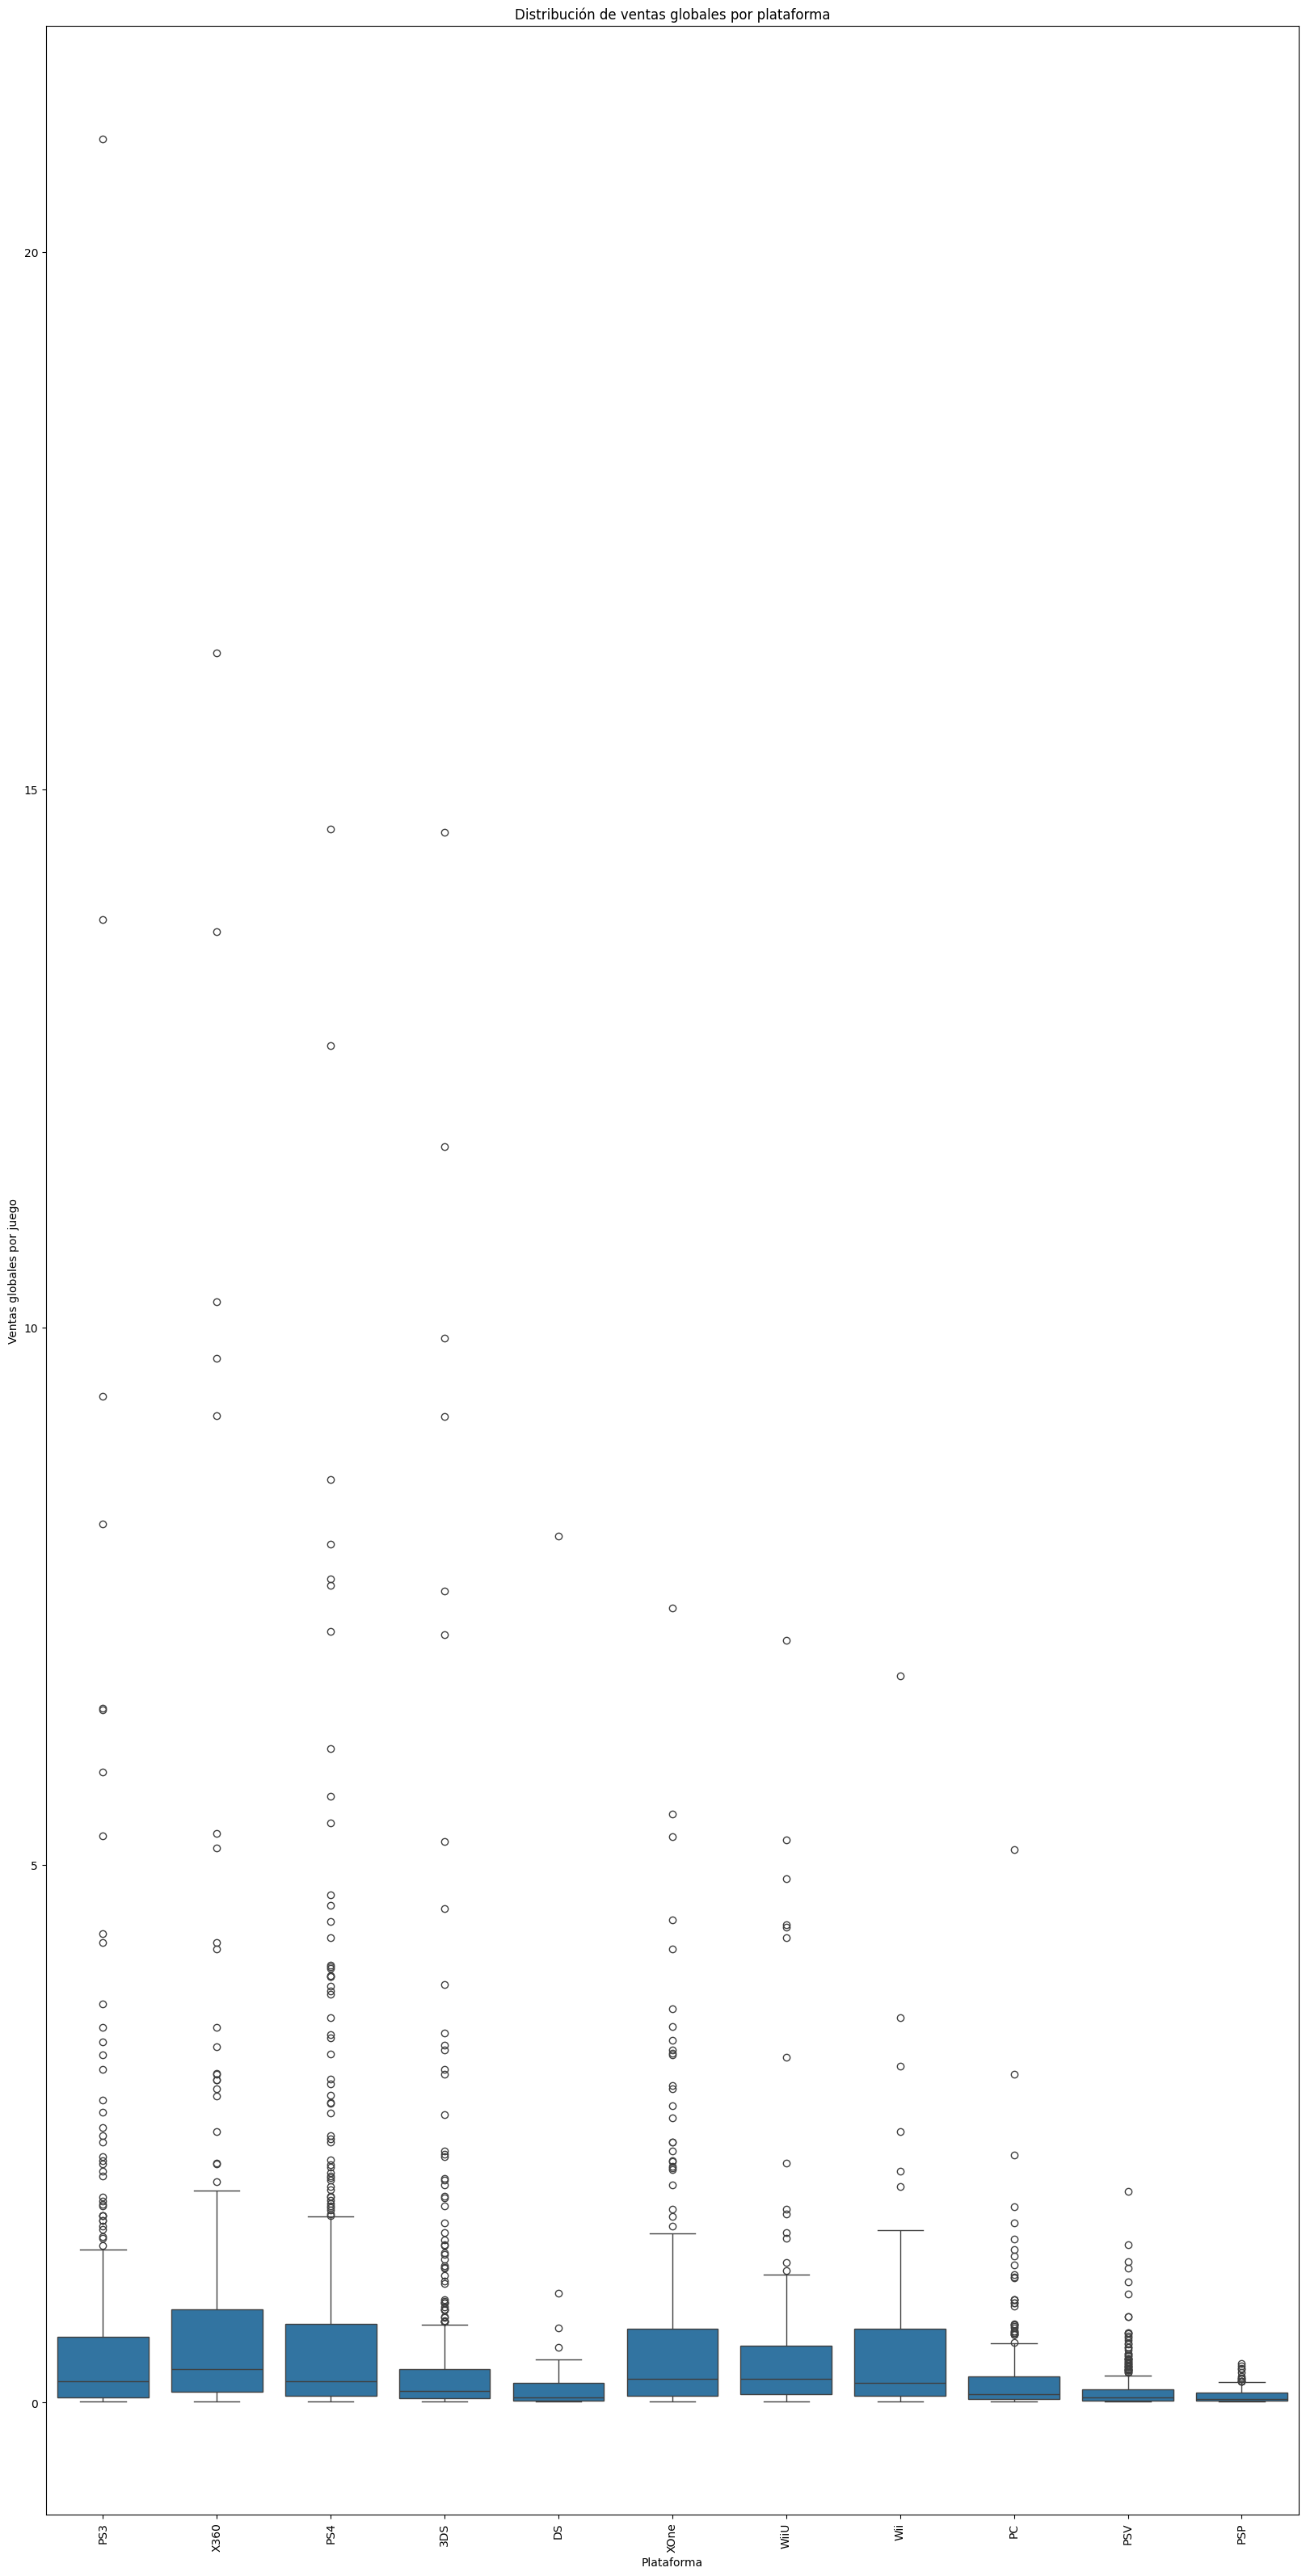

In [ ]:
plt.figure(figsize = (20, 40))

sns.boxplot(data = games_relevante, x = "platform", y = "total_sales")

plt.title("Distribución de ventas globales por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales por juego")
plt.xticks(rotation=90)
plt.show()

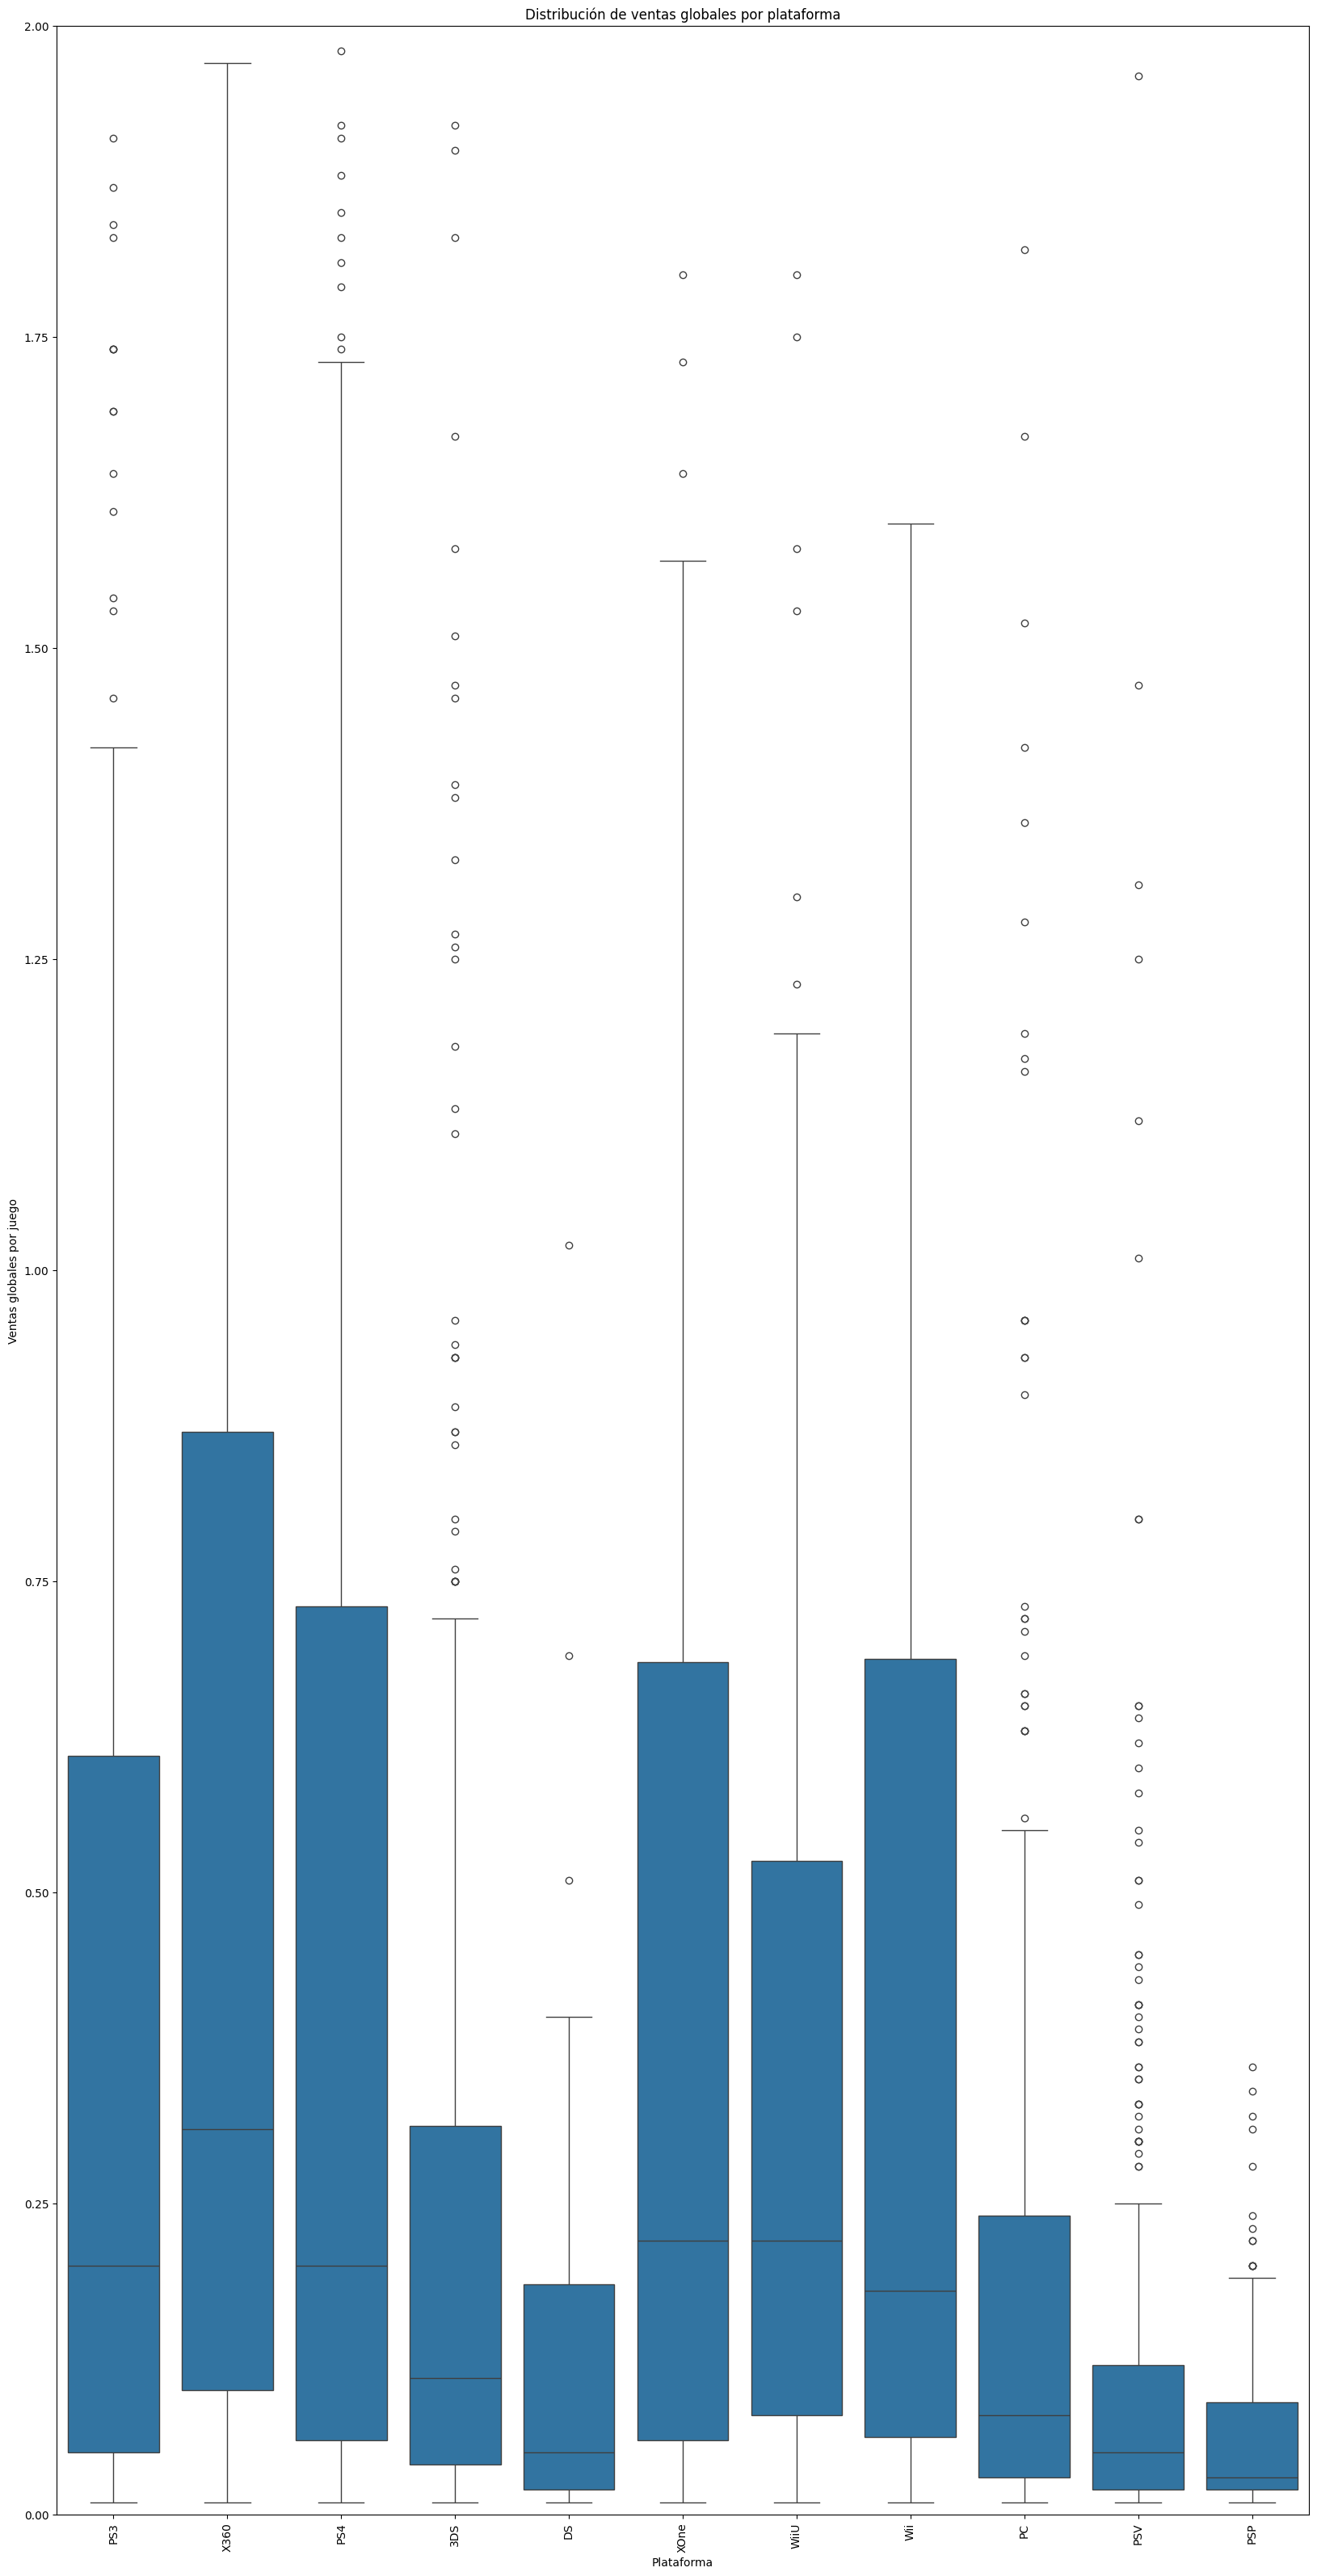

In [ ]:
plt.figure(figsize = (20, 40))

sns.boxplot(data = games_relevante, x = "platform", y = "total_sales")

plt.ylim(0, 2)
plt.title("Distribución de ventas globales por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales por juego")
plt.xticks(rotation=90)
plt.show()

Cálculo de la media y la mediana de las ventas de todos los juegos globalmente

Los resultados muestran que **PS4** presenta las medias más altas del período analizado, especialmente en 2013 y 2014. Esto indica que, durante sus primeros años en el mercado, los títulos lanzados para esta plataforma lograron un desempeño comercial superior al observado en la mayoría de las demás plataformas.

In [ ]:
media_games = games_relevante.groupby(["year_of_release", "platform"])["total_sales"].mean().sort_values(ascending = False).reset_index()

print("Ventas promedio de las plataformas")
print()
print(media_games)
print()
mediana_games = games_relevante.groupby(["year_of_release", "platform"])["total_sales"].median().sort_values(ascending = False).reset_index()
print("Mediana de ventas por plataforma")
print()
print(mediana_games)

Ventas promedio de las plataformas

    year_of_release platform  total_sales
0              2013      PS4     1.624375
1              2014      PS4     1.333333
2              2013     X360     1.181067
3              2013     XOne     0.997895
4              2012     X360     0.940943
5              2013      PS3     0.898810
6              2014     XOne     0.886393
7              2015      PS4     0.867883
8              2015     XOne     0.751750
9              2012      PS3     0.725405
10             2013      Wii     0.715833
11             2014     WiiU     0.710645
12             2012      Wii     0.700323
13             2014      Wii     0.625000
14             2013      3DS     0.621648
15             2015     WiiU     0.583929
16             2012      3DS     0.552258
17             2014     X360     0.551429
18             2012     WiiU     0.548750
19             2014      3DS     0.547000
20             2013     WiiU     0.515476
21             2012       DS     0.47869

Para comprender mejor el comportamiento de las ventas, se compararon la media y la mediana de las ventas por videojuego en cada plataforma y año. Esta comparación es especialmente útil porque permite identificar si los resultados están siendo influenciados por juegos extremadamente exitosos.

Los resultados muestran que, en la mayoría de los casos, la **media es considerablemente superior a la mediana**. Esta diferencia indica que las distribuciones de ventas están sesgadas hacia la derecha, es decir, existen algunos videojuegos con ventas excepcionalmente altas que elevan el promedio, mientras que la mayoría de los títulos registra ventas más moderadas.

In [ ]:
comparacion_games = games_relevante.groupby(["year_of_release", "platform"])["total_sales"].agg(["mean", "median"]).sort_values("mean", ascending = False).reset_index()

print("Comparación entre la media y la mediana en las plataformas")
print()
print(comparacion_games)

Comparación entre la media y la mediana en las plataformas

    year_of_release platform      mean  median
0              2013      PS4  1.624375   1.530
1              2014      PS4  1.333333   0.600
2              2013     X360  1.181067   0.430
3              2013     XOne  0.997895   0.800
4              2012     X360  0.940943   0.435
5              2013      PS3  0.898810   0.310
6              2014     XOne  0.886393   0.440
7              2015      PS4  0.867883   0.180
8              2015     XOne  0.751750   0.245
9              2012      PS3  0.725405   0.305
10             2013      Wii  0.715833   0.185
11             2014     WiiU  0.710645   0.130
12             2012      Wii  0.700323   0.190
13             2014      Wii  0.625000   0.370
14             2013      3DS  0.621648   0.100
15             2015     WiiU  0.583929   0.220
16             2012      3DS  0.552258   0.190
17             2014     X360  0.551429   0.230
18             2012     WiiU  0.548750   0.230


Generación de un dataframe con la plataformas más popular y de mejores resultados (PS4)

Con el fin de estudiar la relación entre las reseñas y las ventas, se seleccionó **PlayStation 4 (PS4)** como plataforma de referencia. Esta elección se justifica porque PS4 fue la plataforma con mayores ventas acumuladas durante el período relevante y una de las más importantes para proyectar tendencias hacia 2017.

El subconjunto resultante contiene **392 videojuegos**, cantidad suficiente para realizar análisis de correlación y visualización con una base sólida de observaciones.

In [ ]:
plataforma_elegida = "PS4"
datos_plataforma_elegida = games_relevante[games_relevante["platform"] == plataforma_elegida].copy()

print("Tamaño del nuevo dataframe:")
print()
print(datos_plataforma_elegida.shape)
print()

print(datos_plataforma_elegida[["platform", "year_of_release", "critic_score", "user_score", "total_sales"]].sample(20))

Tamaño del nuevo dataframe:

(392, 12)

      platform  year_of_release  critic_score  user_score  total_sales
1107       PS4             2016          89.0         8.8         1.66
7539       PS4             2015          62.0         6.8         0.20
8198       PS4             2015          59.0         6.1         0.17
12728      PS4             2015          42.0         4.1         0.06
3011       PS4             2014          71.0         7.1         0.67
767        PS4             2016          90.0         6.1         2.14
4392       PS4             2014          78.0         5.6         0.44
3848       PS4             2014          68.0         6.6         0.52
12761      PS4             2016           NaN         NaN         0.06
2815       PS4             2015          80.0         7.1         0.73
10970      PS4             2016           NaN         NaN         0.08
8208       PS4             2015           NaN         NaN         0.17
14157      PS4             2016      

Generación de un dataframe que contenga los valores de puntuación de la crítica con las ventas totales sin ausentes



In [ ]:
puntuacion_especial = datos_plataforma_elegida.dropna(subset = ["critic_score", "total_sales"]).copy()

print("Filas aleatorias del nuevo dataset")
print()
print(puntuacion_especial[["name", "platform", "critic_score", "total_sales"]].sample(10))

print("tamaño del dataset:")
print()
print(puntuacion_especial.shape)

Filas aleatorias del nuevo dataset

                                  name platform  critic_score  total_sales
11839          Toy Soldiers: War Chest      PS4          62.0         0.07
420                      Madden NFL 16      PS4          83.0         3.24
1848            Dragon Ball: XenoVerse      PS4          69.0         1.10
509    Assassin's Creed IV: Black Flag      PS4          83.0         2.86
143                            FIFA 15      PS4          82.0         6.08
11379                    Shovel Knight      PS4          90.0         0.07
4917             Skylanders SWAP Force      PS4          79.0         0.38
1026                   The Order: 1886      PS4          63.0         1.72
12228                         Terraria      PS4          83.0         0.07
8249                   Toukiden Kiwami      PS4          74.0         0.16
tamaño del dataset:

(252, 12)


Construcción del grafico de dispersión para ver la relación entre el puntaje especial y las ventas totales

A primera vista se observa una tendencia positiva moderada: los juegos que reciben puntuaciones más altas por parte de los críticos suelen registrar mayores niveles de ventas. Los títulos con puntuaciones inferiores a 60 rara vez alcanzan ventas elevadas, mientras que los videojuegos con calificaciones superiores a 75 concentran gran parte de los mayores éxitos comerciales de la plataforma.

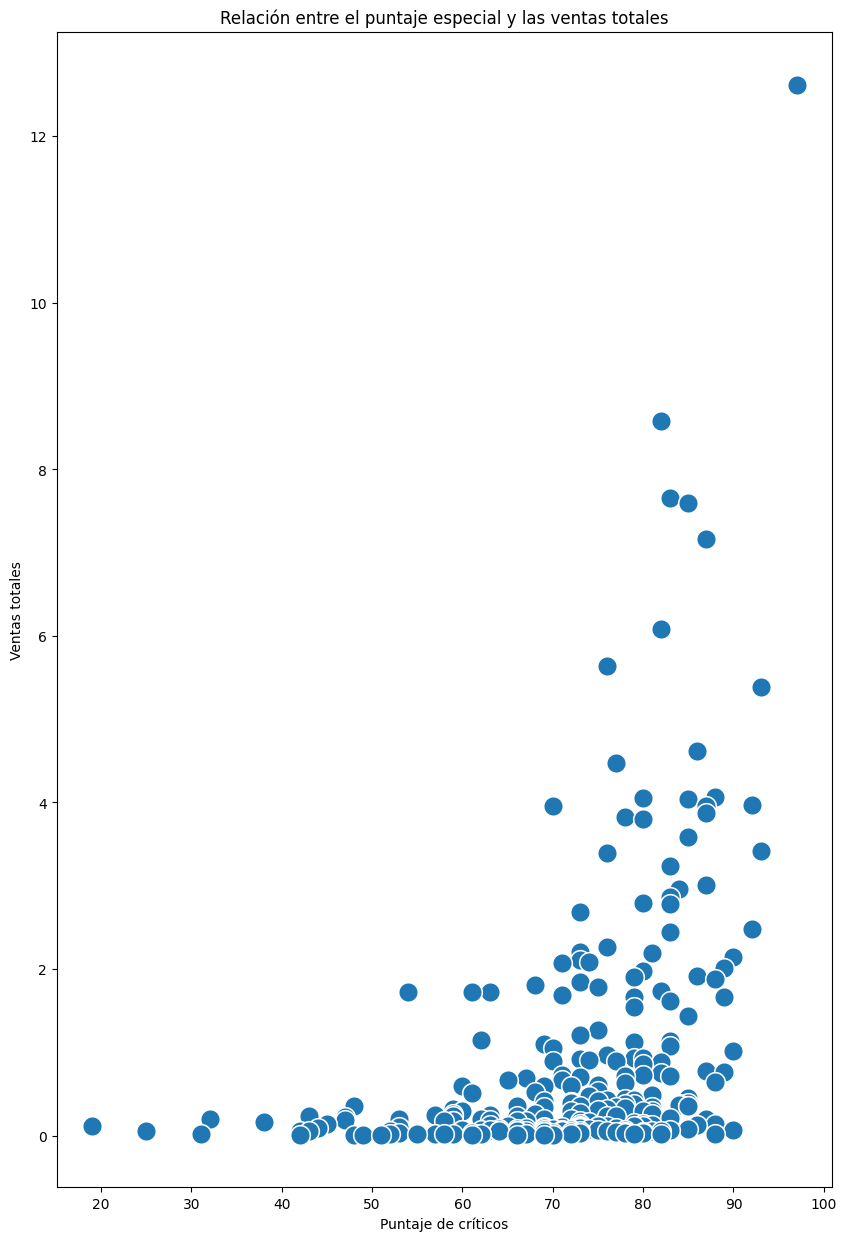

In [ ]:
plt.figure(figsize = (10, 15))

sns.scatterplot(data = puntuacion_especial, x = "critic_score", y = "total_sales", s = 200)

plt.title("Relación entre el puntaje especial y las ventas totales")
plt.xlabel("Puntaje de críticos")
plt.ylabel("Ventas totales")
plt.show()



In [ ]:
correlacion_critic = puntuacion_especial["critic_score"].corr(puntuacion_especial["total_sales"])
print("La correlación entre el puntaje especial y las ventas totales es de:")
print()
print(correlacion_critic)

La correlación entre el puntaje especial y las ventas totales es de:

0.40656790206178095


Preparación de datos basados en los puntajes de los usuarios

In [ ]:
preparacion_user_total = datos_plataforma_elegida.dropna(subset = ["user_score", "total_sales"])
print(preparacion_user_total[["name", "platform", "user_score", "total_sales"]].sample(10))
print()
print("El tamaño de este dataset es de:")
print()
print(preparacion_user_total.shape)


                                     name platform  user_score  total_sales
14404                    Prison Architect      PS4         8.0         0.03
7906             Singstar: Ultimate Party      PS4         4.1         0.19
14902  Aegis of Earth: Protonovus Assault      PS4         7.8         0.02
10289      RIGS: Mechanized Combat League      PS4         7.9         0.11
8190         Back to the Future: The Game      PS4         7.1         0.18
539                       Mortal Kombat X      PS4         7.7         2.78
6638                PlayStation VR Worlds      PS4         7.1         0.26
5746                            Tropico 5      PS4         7.1         0.32
12391                       Assetto Corsa      PS4         6.2         0.06
16135             Super Stardust Ultra VR      PS4         6.2         0.01

El tamaño de este dataset es de:

(257, 12)


Construcción de un diagrama de dispersion para ver la correlación entre el puntaje de usuarios y el total de ventas

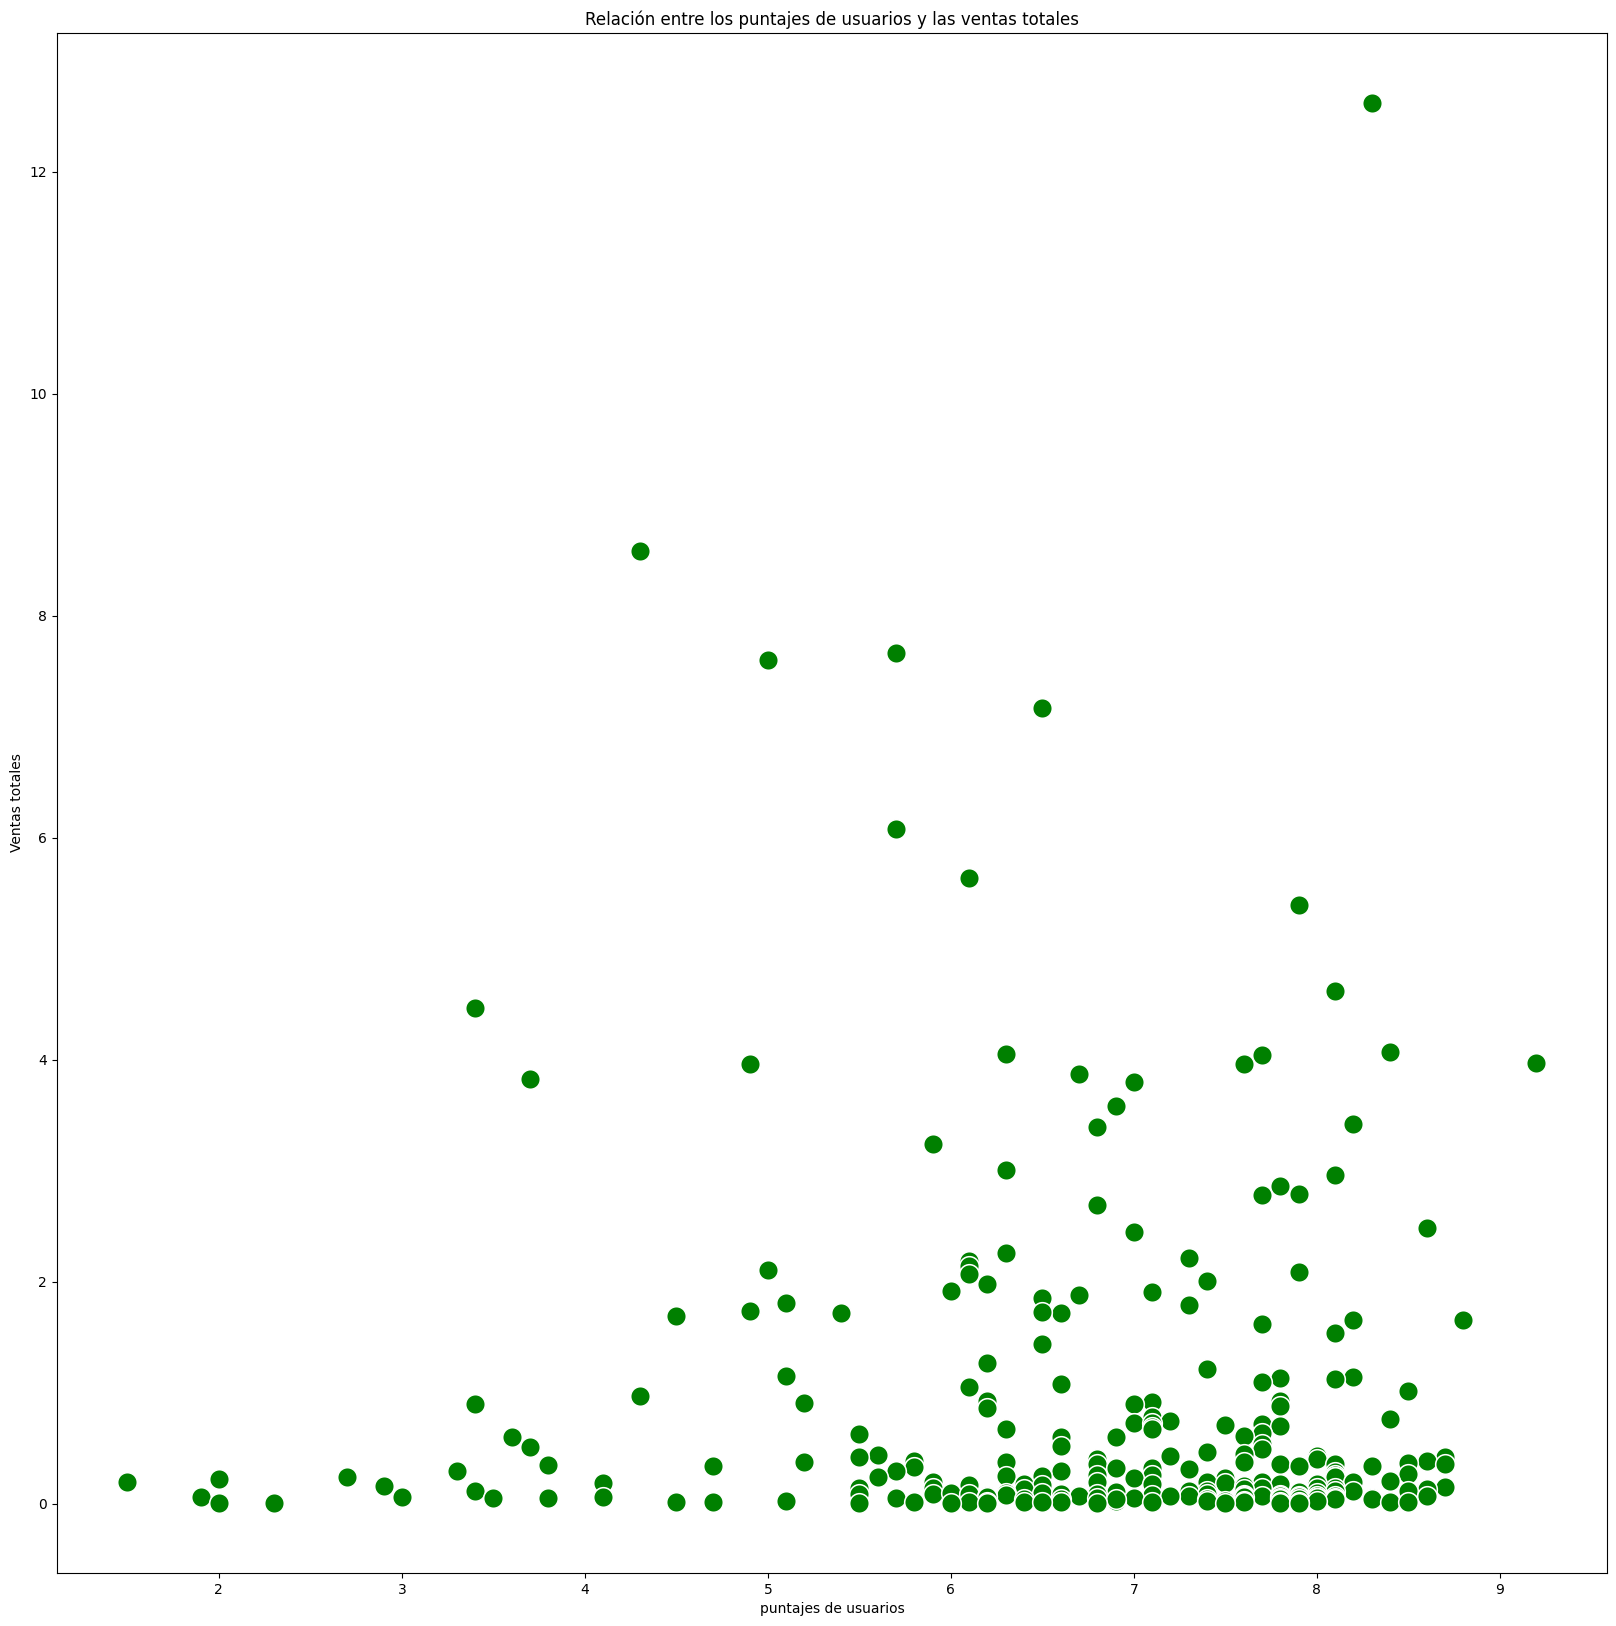

In [ ]:
plt.figure(figsize = (20, 20))
sns.scatterplot(data = preparacion_user_total , x = "user_score" , y = "total_sales", c = "green", s = 200)
plt.title("Relación entre los puntajes de usuarios y las ventas totales")
plt.xlabel("puntajes de usuarios")
plt.ylabel("Ventas totales")
plt.show()

Cálculo de correlación numérica entre los puntajes de usuarios con las ventas totales

## Correlación entre las calificaciones de los usuarios y las ventas

Para complementar el análisis visual, se calculó el coeficiente de correlación entre las puntuaciones otorgadas por los usuarios y las ventas globales de los videojuegos de PS4.

El resultado obtenido fue:

- Correlación = **-0.032**

Este valor se encuentra extremadamente cerca de cero, lo que indica que prácticamente **no existe una relación lineal entre las calificaciones de los usuarios y las ventas totales de los videojuegos**.

In [ ]:
correlacion_user = preparacion_user_total["user_score"].corr(preparacion_user_total["total_sales"])
print("La correlación entre los puntajes de usuarios con las ventas totales es de:")
print()
print(correlacion_user)

La correlación entre los puntajes de usuarios con las ventas totales es de:

-0.031957110204556424


Análisis de las ventas acumuladas de los juegos de la plataforma elegida en otras plataformas

In [ ]:
nombres_unicos = datos_plataforma_elegida["name"].unique()
juegos_en_otras_plat = games_relevante[games_relevante["name"].isin(nombres_unicos)].copy()
ventas_totales_otros_juegos = juegos_en_otras_plat.groupby(["name", "platform"])["total_sales"].sum().sort_values(ascending = False).reset_index()
print(ventas_totales_otros_juegos.head(10))

                             name platform  total_sales
0              Grand Theft Auto V      PS3        21.05
1              Grand Theft Auto V     X360        16.27
2       Call of Duty: Black Ops 3      PS4        14.63
3              Grand Theft Auto V      PS4        12.62
4            Call of Duty: Ghosts     X360        10.24
5            Call of Duty: Ghosts      PS3         9.36
6                       Minecraft     X360         9.18
7                         FIFA 16      PS4         8.58
8    Star Wars Battlefront (2015)      PS4         7.98
9  Call of Duty: Advanced Warfare      PS4         7.66


## Comparación de las ventas de los mismos videojuegos en distintas plataformas

Para complementar el análisis de PS4, se compararon las ventas de los mismos videojuegos en distintas plataformas. El objetivo fue determinar si el desempeño comercial de un título depende únicamente de su calidad o si la plataforma donde se lanza también desempeña un papel importante.

El diagrama de caja muestra diferencias notables entre plataformas. Algunas presentan medianas y rangos de ventas superiores, indicando que los mismos videojuegos tienden a vender mejor en determinados ecosistemas.

Entre las plataformas analizadas, **Wii**, **Xbox 360**, **PS4** y **Xbox One** muestran distribuciones de ventas relativamente más altas. En estas plataformas, los juegos presentan mayores ventas típicas y una mayor probabilidad de alcanzar resultados comerciales destacados.

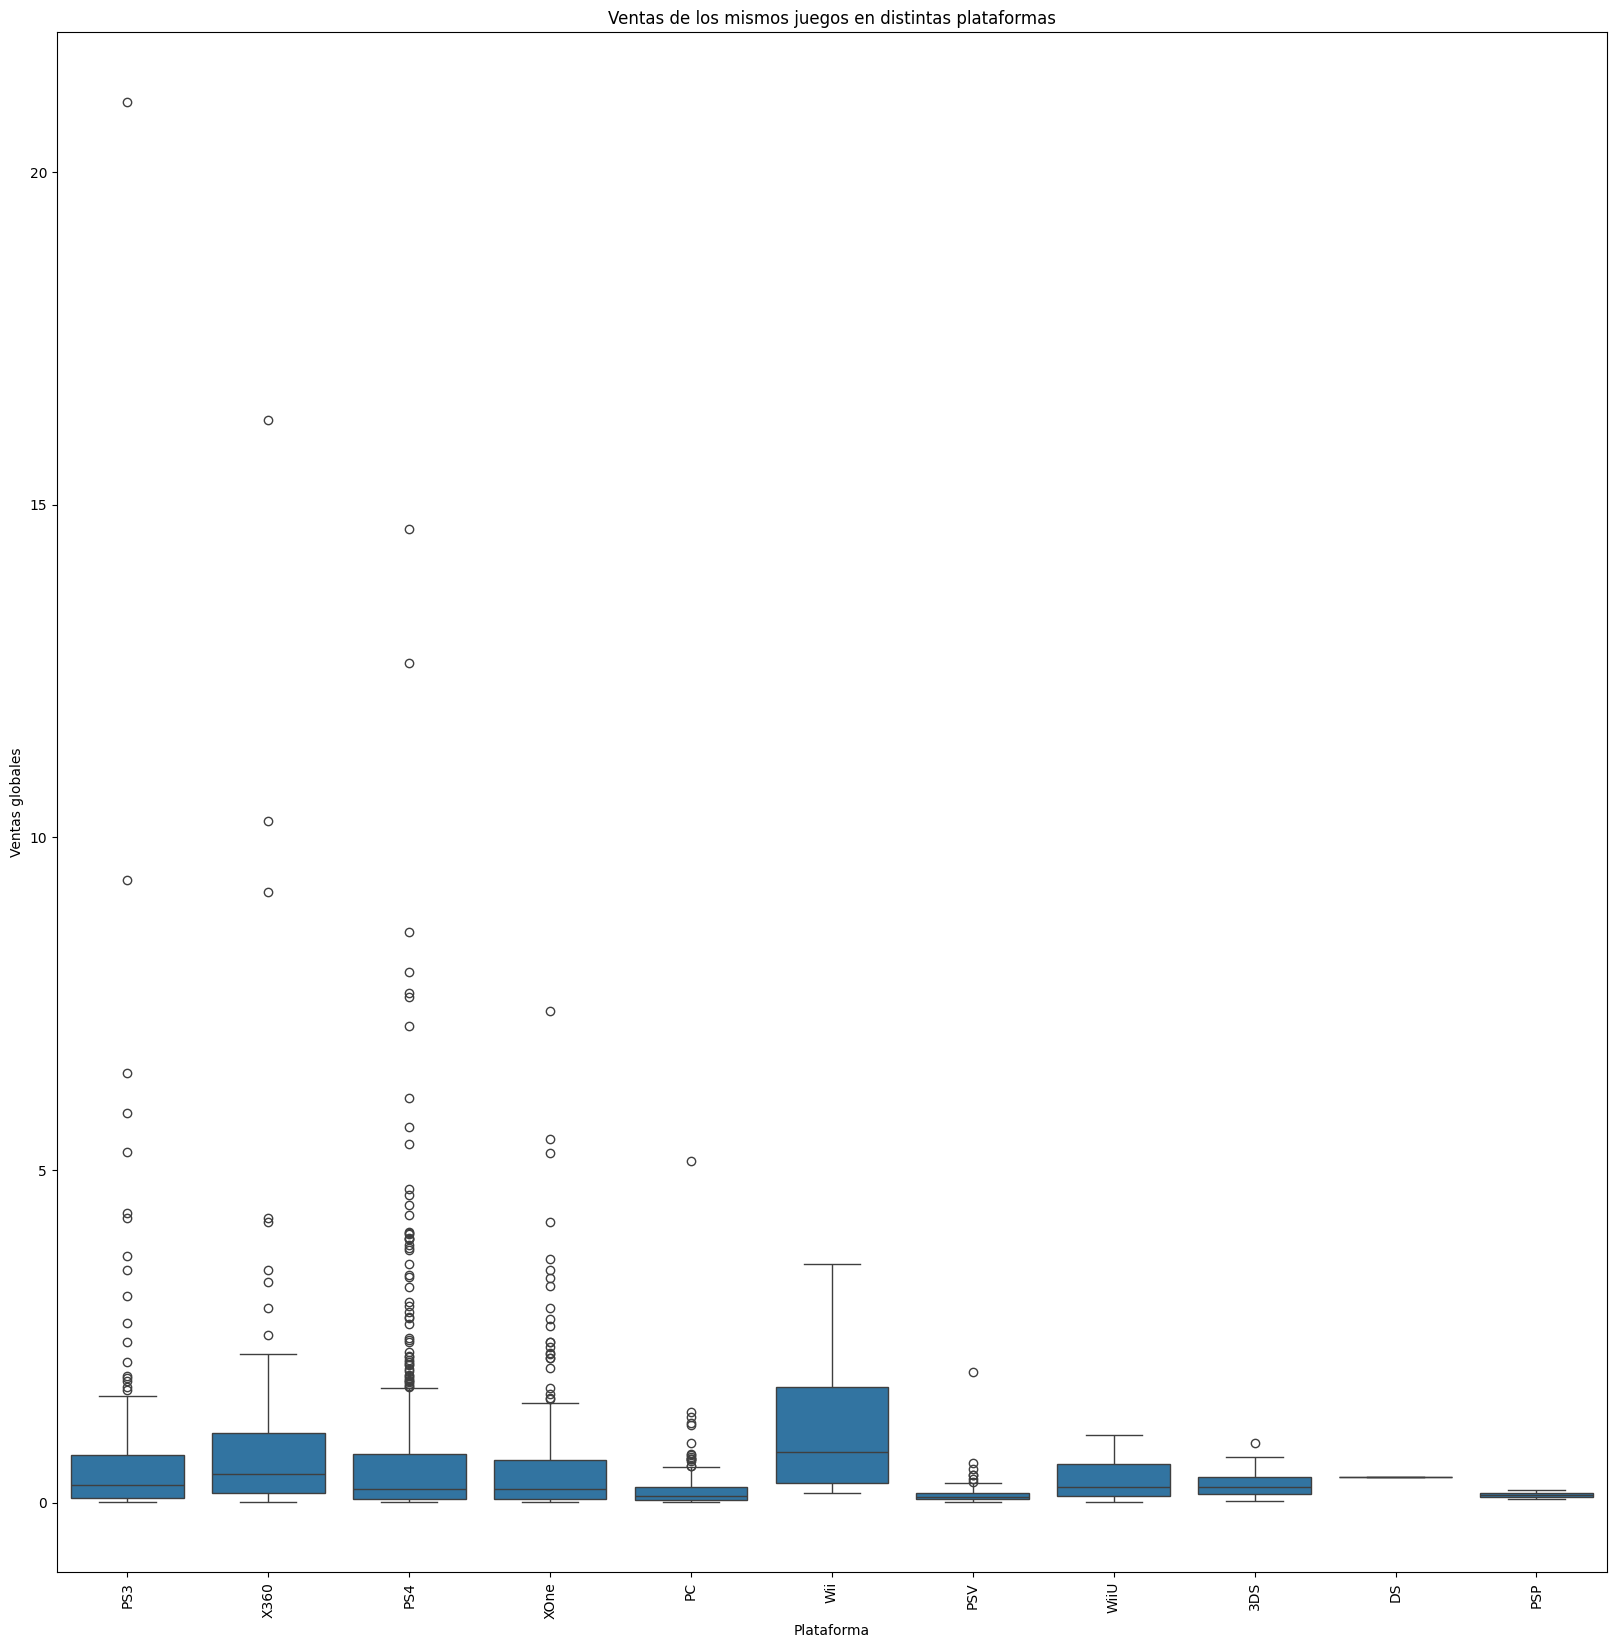

In [ ]:
plt.figure(figsize = (20, 20))
sns.boxplot(
    data=ventas_totales_otros_juegos,
    x="platform",
    y="total_sales"
)

plt.title("Ventas de los mismos juegos en distintas plataformas")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales")
plt.xticks(rotation=90)
plt.show()


Al limitar la escala del gráfico a un máximo de 2 millones de dólares por juego, resulta mucho más sencillo comparar el comportamiento típico de las ventas entre plataformas sin que los títulos extremadamente exitosos dominen la visualización.

Se observa que las plataformas **Wii**, **Xbox 360** y **PS4** presentan algunas de las medianas más elevadas dentro del conjunto analizado. Esto indica que, para un videojuego promedio, estas plataformas tienden a generar mayores ventas que otras alternativas del mercado.

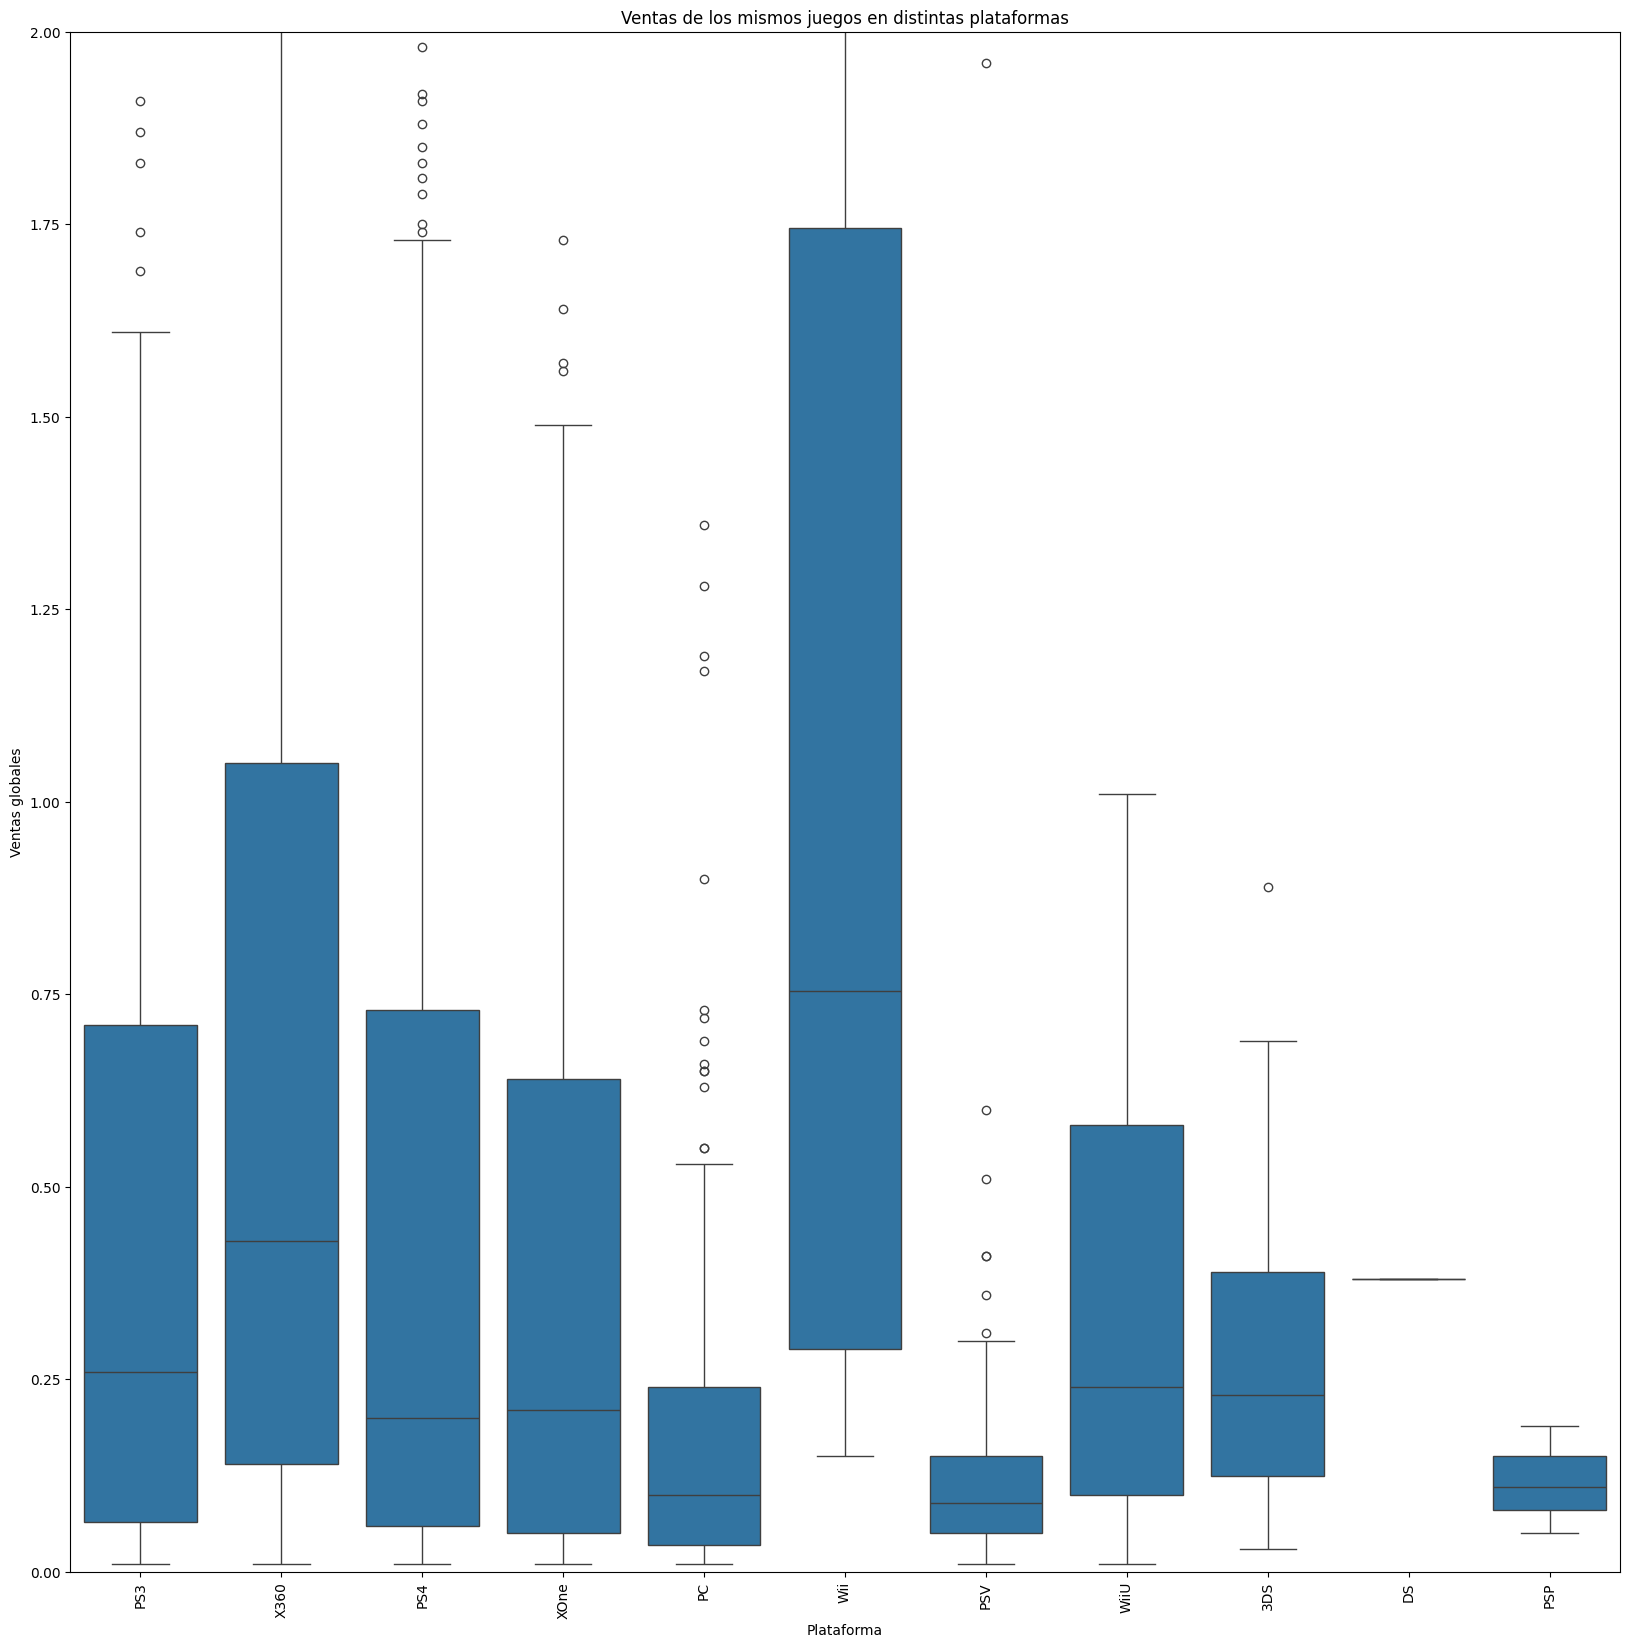

In [ ]:
plt.figure(figsize = (20, 20))
sns.boxplot(data = ventas_totales_otros_juegos,
    x="platform",
    y="total_sales")

plt.title("Ventas de los mismos juegos en distintas plataformas")
plt.xlabel("Plataforma")
plt.ylim(0,2)
plt.ylabel("Ventas globales")
plt.xticks(rotation=90)
plt.show()


Generación de una tabla resumen que muestra cuántos juegos hay por cada género en el período relevante

In [ ]:
juegos_por_genero = games_relevante["genre"].value_counts().reset_index().copy()
print("Cantidad de juegos por género:")
print()
print(juegos_por_genero)

Cantidad de juegos por género:

           genre  count
0         Action   1031
1   Role-Playing    370
2      Adventure    302
3         Sports    268
4        Shooter    235
5           Misc    192
6         Racing    115
7       Fighting    109
8       Platform     85
9     Simulation     80
10      Strategy     71
11        Puzzle     28


Graficación de cuantos juegos tiene cada género en el periodo relevante

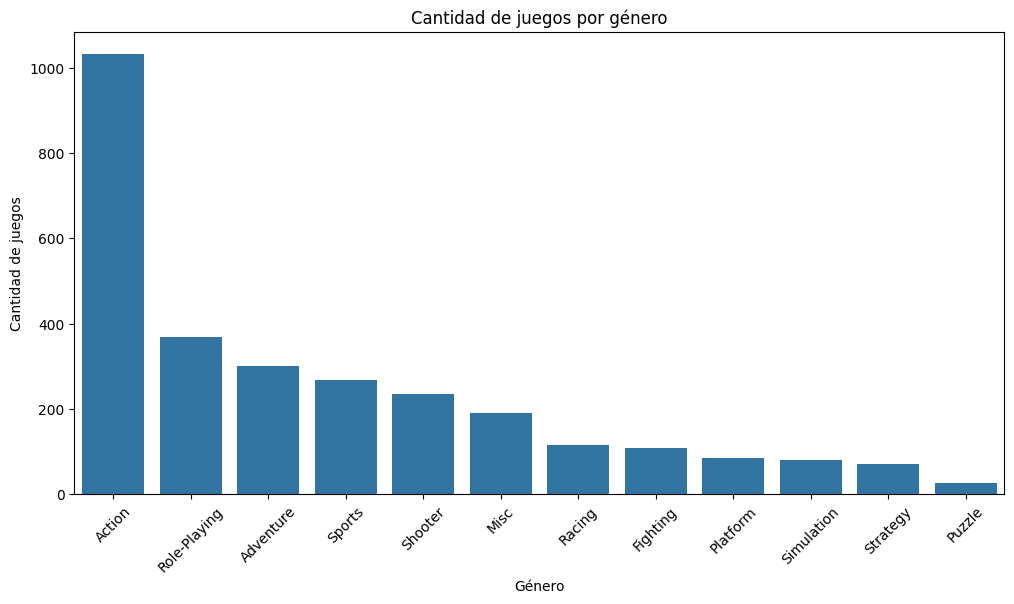

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=games_relevante,
    x="genre",
    order = games_relevante["genre"].value_counts().index)

plt.title("Cantidad de juegos por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.show()

Para complementar el análisis de las distribuciones de ventas, se calcularon tanto la media como la mediana de las ventas globales por plataforma. La comparación entre ambas métricas permite identificar el efecto de los videojuegos con ventas excepcionalmente altas sobre los resultados generales.

Las mayores ventas promedio corresponden a:

- Xbox 360: 0.81 millones
- PS4: 0.80 millones
- Wii: 0.66 millones
- Xbox One: 0.65 millones
- PS3: 0.59 millones

Sin embargo, al analizar las medianas se observan diferencias importantes:

- Xbox 360: 0.31 millones
- Wii U: 0.22 millones
- Xbox One: 0.22 millones
- PS4: 0.20 millones
- PS3: 0.20 millones

La diferencia entre la media y la mediana en plataformas como PS4, Xbox 360 y Xbox One indica que una parte importante de las ventas está impulsada por unos pocos títulos muy exitosos. Estos videojuegos elevan considerablemente los promedios, mientras que la mayoría de los títulos registra ventas más moderadas.

In [ ]:
promedio_plataforma = (
    games_relevante
    .groupby("platform")["total_sales"]
    .mean()
    .sort_values(ascending=False)
)

mediana_plataforma = (
    games_relevante
    .groupby("platform")["total_sales"]
    .median()
    .sort_values(ascending=False)
)

print("Ventas promedio por plataforma:")
print()
print(promedio_plataforma)

print()
print("Mediana de ventas por plataforma:")
print()
print(mediana_plataforma)

Ventas promedio por plataforma:

platform
X360    0.810068
PS4     0.801378
Wii     0.655000
XOne    0.645020
PS3     0.585781
WiiU    0.559116
3DS     0.491439
DS      0.404839
PC      0.250600
PSV     0.119659
PSP     0.064682
Name: total_sales, dtype: float64

Mediana de ventas por plataforma:

platform
X360    0.31
WiiU    0.22
XOne    0.22
PS4     0.20
PS3     0.20
Wii     0.18
3DS     0.11
PC      0.08
DS      0.05
PSV     0.05
PSP     0.03
Name: total_sales, dtype: float64


Cantidad de juegos por género:

           genre  count
0         Action   1031
1   Role-Playing    370
2      Adventure    302
3         Sports    268
4        Shooter    235
5           Misc    192
6         Racing    115
7       Fighting    109
8       Platform     85
9     Simulation     80
10      Strategy     71
11        Puzzle     28


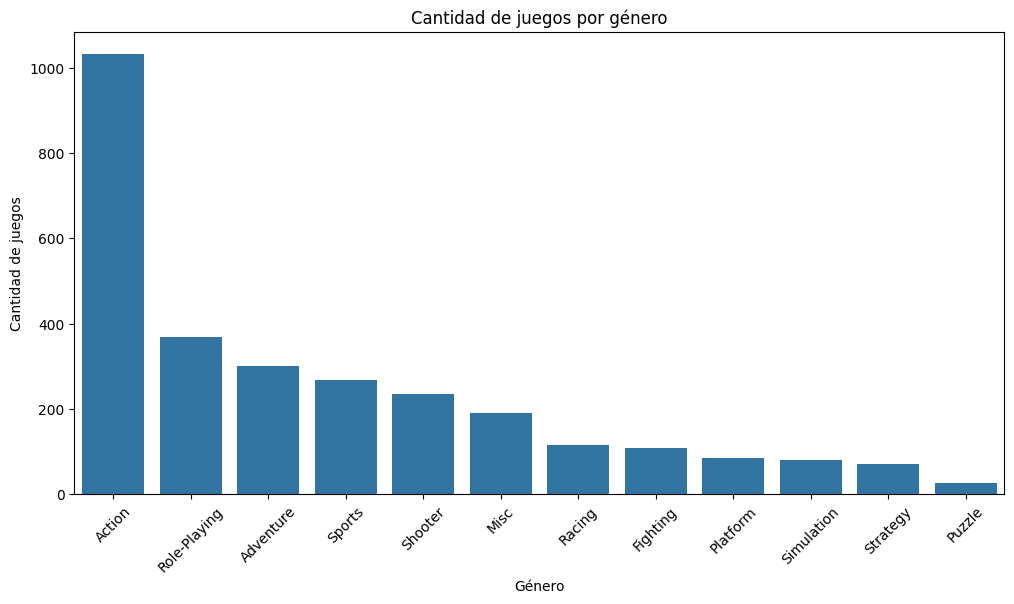

Ventas totales por género:

           genre  total_sales
0         Action       441.12
1        Shooter       304.73
2   Role-Playing       192.80
3         Sports       181.07
4           Misc        85.04
5       Platform        61.00
6         Racing        53.50
7       Fighting        44.49
8     Simulation        35.12
9      Adventure        29.43
10      Strategy        13.34
11        Puzzle         4.89


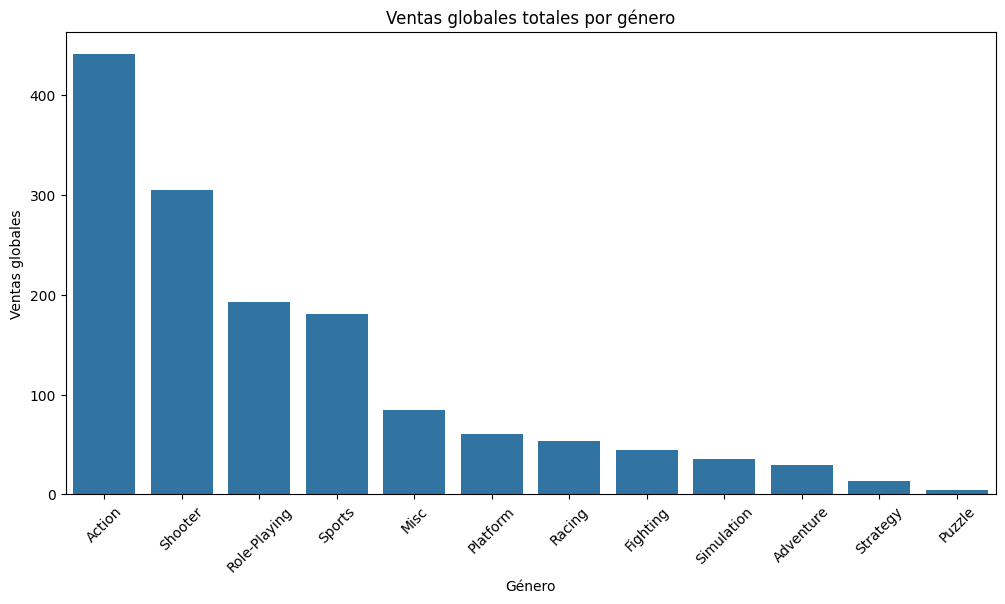

Ventas promedio por género:

           genre  total_sales
0        Shooter     1.296723
1       Platform     0.717647
2         Sports     0.675634
3   Role-Playing     0.521081
4         Racing     0.465217
5           Misc     0.442917
6     Simulation     0.439000
7         Action     0.427856
8       Fighting     0.408165
9       Strategy     0.187887
10        Puzzle     0.174643
11     Adventure     0.097450


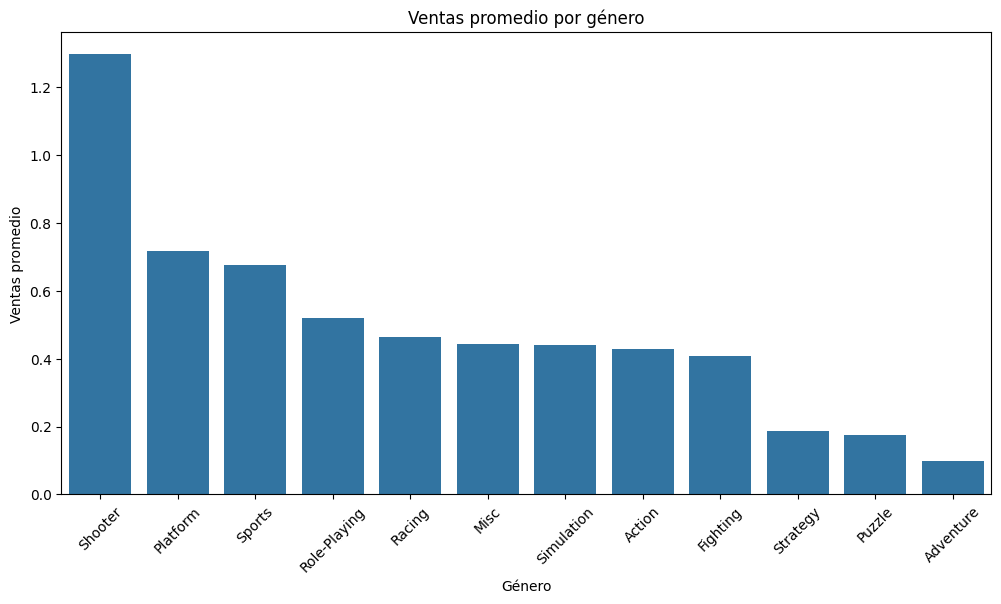

Mediana de ventas por género:

           genre  total_sales
0        Shooter        0.440
1         Sports        0.240
2       Platform        0.210
3   Role-Playing        0.140
4         Racing        0.140
5       Fighting        0.130
6         Action        0.120
7           Misc        0.120
8     Simulation        0.120
9       Strategy        0.080
10        Puzzle        0.045
11     Adventure        0.030


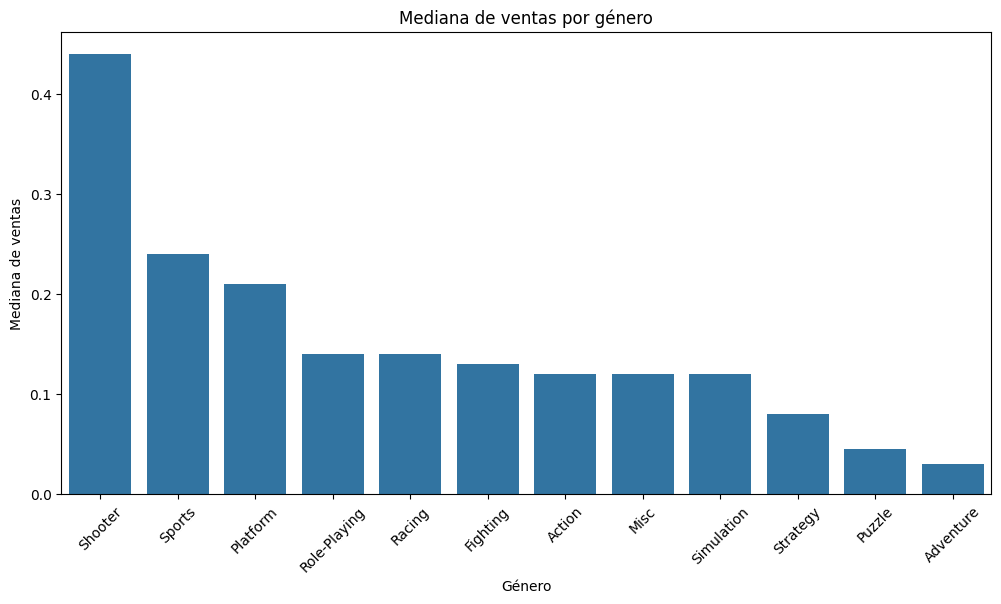

Resumen de ventas por género:

                 sum      mean  median  count
genre                                        
Action        441.12  0.427856   0.120   1031
Shooter       304.73  1.296723   0.440    235
Role-Playing  192.80  0.521081   0.140    370
Sports        181.07  0.675634   0.240    268
Misc           85.04  0.442917   0.120    192
Platform       61.00  0.717647   0.210     85
Racing         53.50  0.465217   0.140    115
Fighting       44.49  0.408165   0.130    109
Simulation     35.12  0.439000   0.120     80
Adventure      29.43  0.097450   0.030    302
Strategy       13.34  0.187887   0.080     71
Puzzle          4.89  0.174643   0.045     28


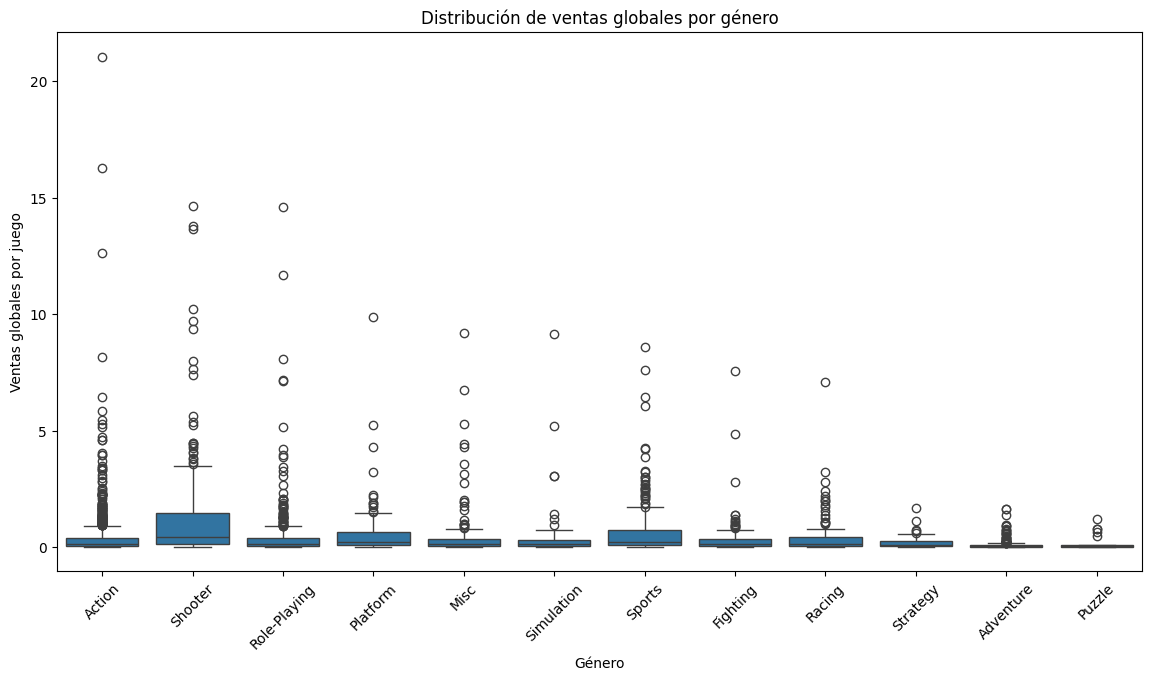

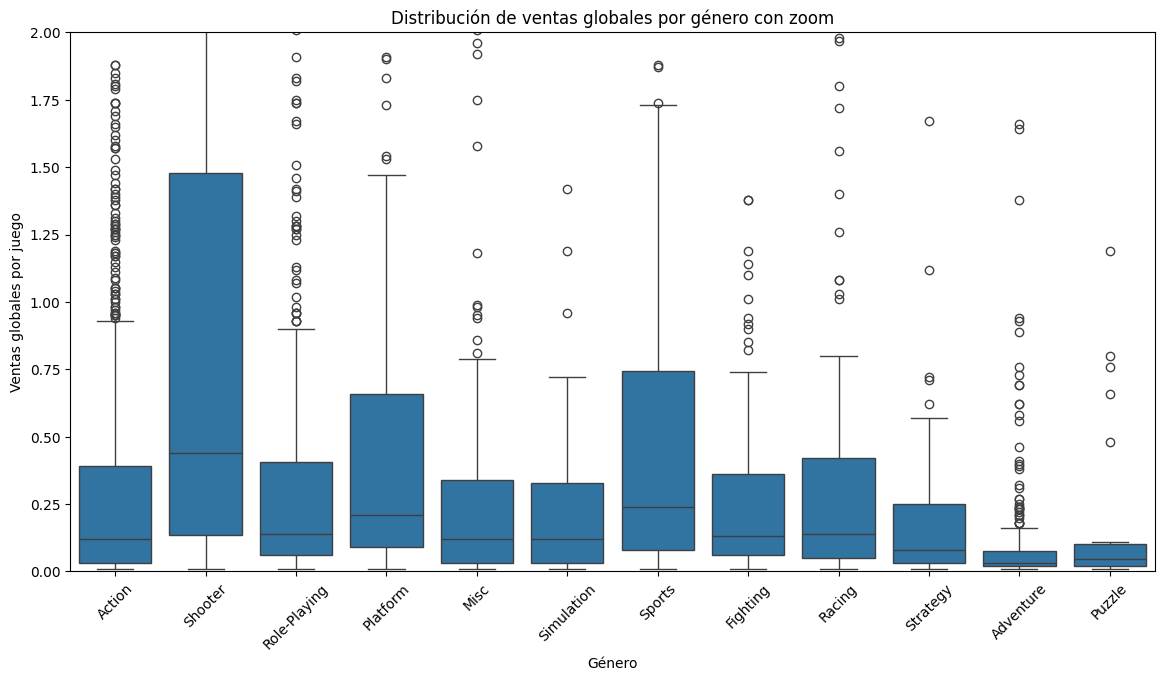

Top 5 plataformas en NA:

platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 plataformas en UE:

platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:

platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64
Cuotas de mercado de plataformas en NA:

platform
X360    0.236983
PS4     0.184003
PS3     0.174933
XOne    0.157571
3DS     0.093592
Name: na_sales, dtype: float64

Cuotas de mercado de plataformas en UE:

platform
PS4     0.278383
PS3     0.210844
X360    0.147034
XOne    0.101792
3DS     0.084132
Name: eu_sales, dtype: float64

Cuotas de mercado de plataformas en JP:

platform
3DS     0.455862
PS3     0.183249
PSV     0.109253
PS4     0.082875
WiiU    0.067556
Name: jp_sales, dtype: float64


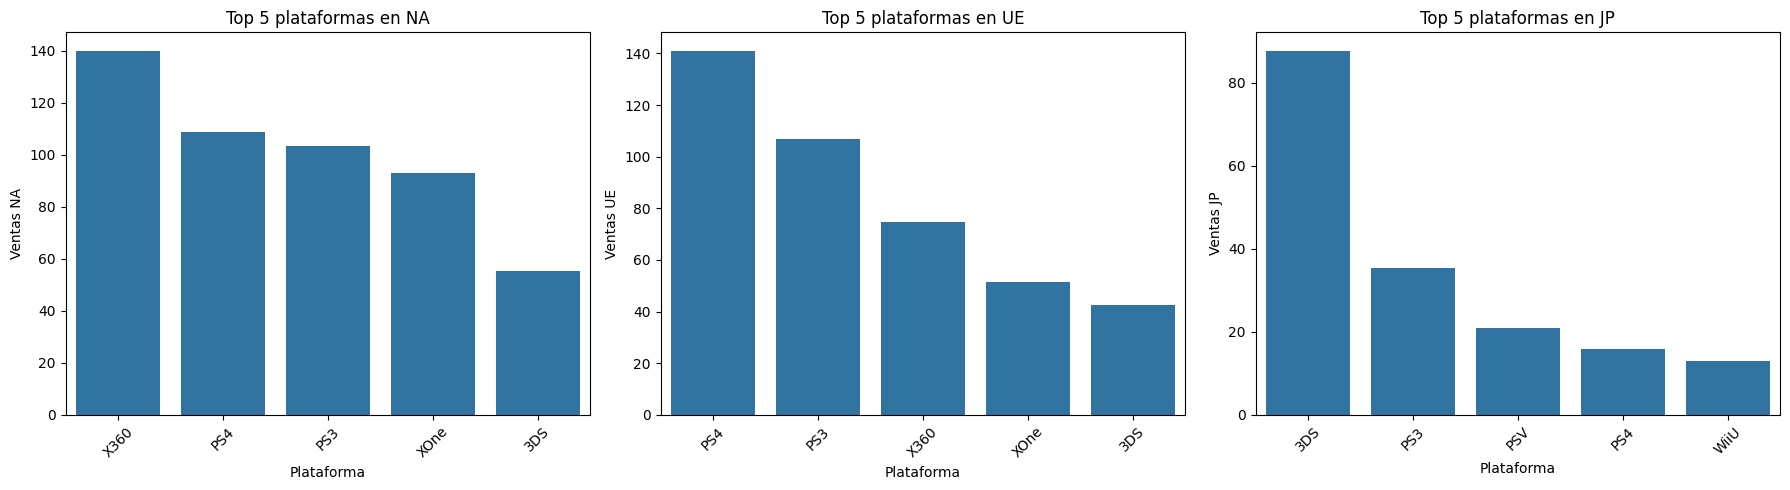

Top 5 géneros en NA:

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Top 5 géneros en UE:

genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Top 5 géneros en JP:

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


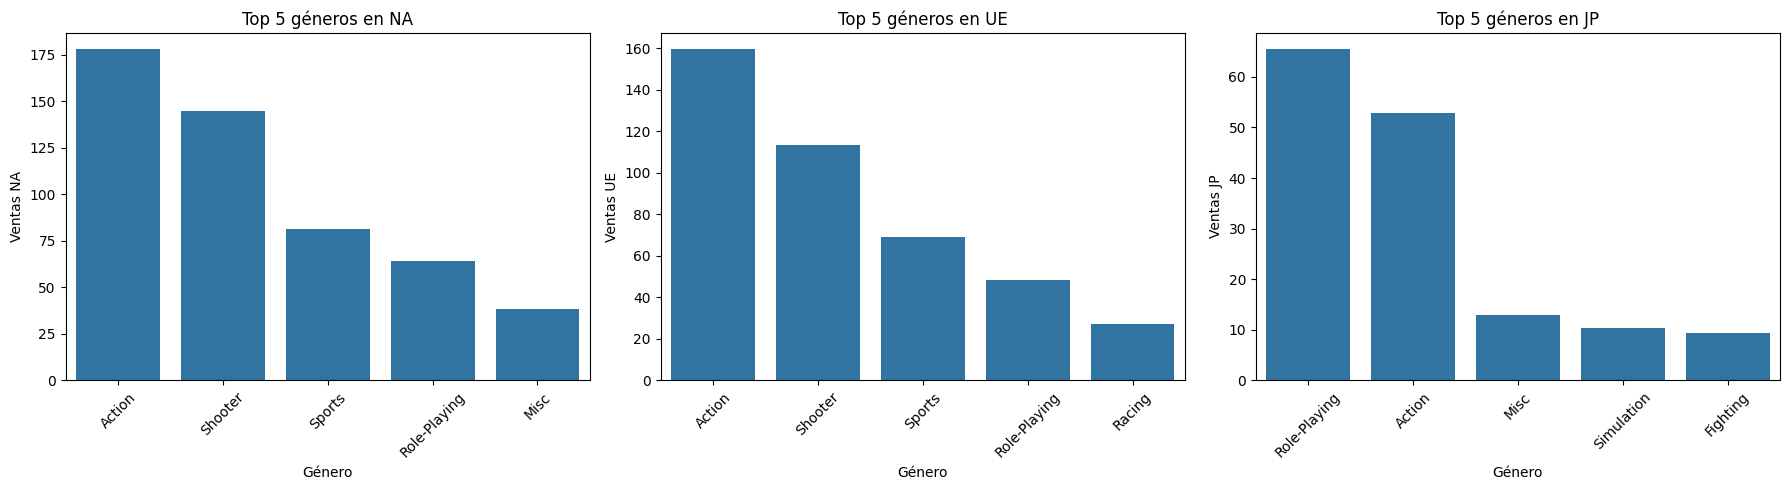

Ventas por clasificación ESRB y región:

        na_sales  eu_sales  jp_sales
rating                              
M         231.57    193.96     21.20
E         114.37    113.03     28.33
0         103.31     91.50    108.84
E10+       75.70     55.37      8.19
T          66.02     52.96     26.02


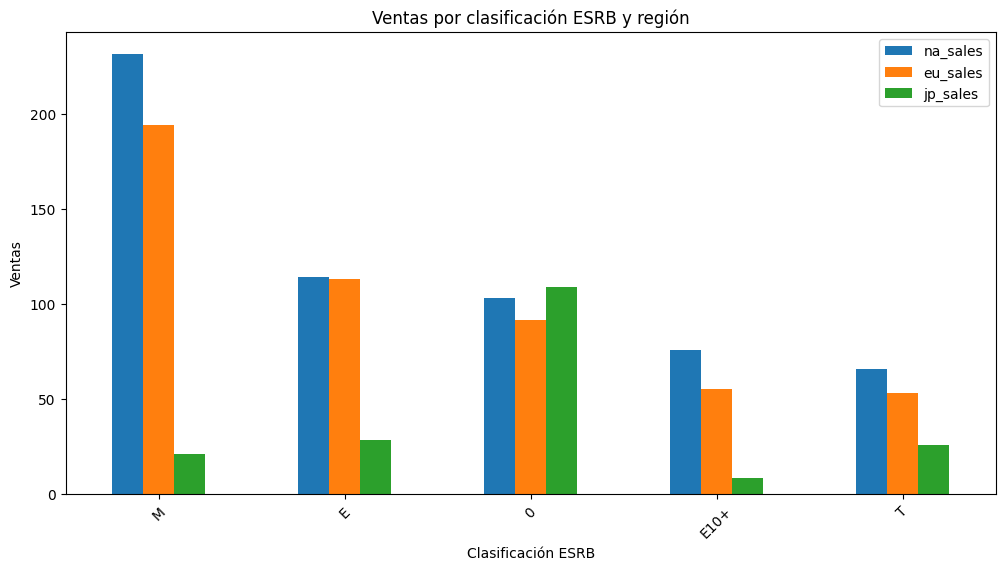

Plataformas disponibles:

['3DS' 'DS' 'PC' 'PS3' 'PS4' 'PSP' 'PSV' 'Wii' 'WiiU' 'X360' 'XOne']
Cantidad de calificaciones de XOne:
182
Cantidad de calificaciones de PC:
206
Hipótesis 1:
H0: Las calificaciones promedio de usuarios de XOne y PC son iguales.
H1: Las calificaciones promedio de usuarios de XOne y PC son diferentes.

p-value:
0.5489537965134912
No rechazamos H0: no hay evidencia suficiente para decir que las calificaciones promedio son diferentes.
Cantidad de calificaciones de Action:
523
Cantidad de calificaciones de Sports:
195
Hipótesis 2:
H0: Las calificaciones promedio de usuarios de Action y Sports son iguales.
H1: Las calificaciones promedio de usuarios de Action y Sports son diferentes.

p-value:
4.24307776572644e-20
Rechazamos H0: hay evidencia suficiente para decir que las calificaciones promedio son diferentes.
RESUMEN GENERAL DEL PROYECTO

Período relevante utilizado:
2012 - 2016

Plataformas con mayores ventas recientes:
  platform  total_sales
0      PS4       

In [ ]:
# ============================================================
# DISTRIBUCIÓN GENERAL DE JUEGOS POR GÉNERO
# ============================================================

juegos_por_genero = games_relevante["genre"].value_counts().reset_index().copy()

print("Cantidad de juegos por género:")
print()
print(juegos_por_genero)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=games_relevante,
    x="genre",
    order=games_relevante["genre"].value_counts().index
)

plt.title("Cantidad de juegos por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# VENTAS TOTALES POR GÉNERO
# ============================================================

ventas_genero = (
    games_relevante
    .groupby("genre")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Ventas totales por género:")
print()
print(ventas_genero)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=ventas_genero,
    x="genre",
    y="total_sales"
)

plt.title("Ventas globales totales por género")
plt.xlabel("Género")
plt.ylabel("Ventas globales")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# VENTAS PROMEDIO POR GÉNERO
# ============================================================

promedio_genero = (
    games_relevante
    .groupby("genre")["total_sales"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Ventas promedio por género:")
print()
print(promedio_genero)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=promedio_genero,
    x="genre",
    y="total_sales"
)

plt.title("Ventas promedio por género")
plt.xlabel("Género")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# MEDIANA DE VENTAS POR GÉNERO
# ============================================================

mediana_genero = (
    games_relevante
    .groupby("genre")["total_sales"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

print("Mediana de ventas por género:")
print()
print(mediana_genero)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=mediana_genero,
    x="genre",
    y="total_sales"
)

plt.title("Mediana de ventas por género")
plt.xlabel("Género")
plt.ylabel("Mediana de ventas")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# RESUMEN DE VENTAS POR GÉNERO
# ============================================================

resumen_genero = (
    games_relevante
    .groupby("genre")["total_sales"]
    .agg(["sum", "mean", "median", "count"])
    .sort_values("sum", ascending=False)
)

print("Resumen de ventas por género:")
print()
print(resumen_genero)


# ============================================================
# BOXPLOT DE VENTAS POR GÉNERO
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=games_relevante,
    x="genre",
    y="total_sales"
)

plt.title("Distribución de ventas globales por género")
plt.xlabel("Género")
plt.ylabel("Ventas globales por juego")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(14, 7))

sns.boxplot(
    data=games_relevante,
    x="genre",
    y="total_sales"
)

plt.ylim(0, 2)
plt.title("Distribución de ventas globales por género con zoom")
plt.xlabel("Género")
plt.ylabel("Ventas globales por juego")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# PERFIL DE USUARIO POR REGIÓN
# ============================================================

# ============================================================
# TOP 5 PLATAFORMAS POR REGIÓN
# ============================================================

top_na_platforms = (
    games_relevante
    .groupby("platform")["na_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_ue_platforms = (
    games_relevante
    .groupby("platform")["eu_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_jp_platforms = (
    games_relevante
    .groupby("platform")["jp_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 plataformas en NA:")
print()
print(top_na_platforms)

print()
print("Top 5 plataformas en UE:")
print()
print(top_ue_platforms)

print()
print("Top 5 plataformas en JP:")
print()
print(top_jp_platforms)


# ============================================================
# CUOTAS DE MERCADO DE PLATAFORMAS POR REGIÓN
# ============================================================

cuota_na_platforms = top_na_platforms / games_relevante["na_sales"].sum()
cuota_ue_platforms = top_ue_platforms / games_relevante["eu_sales"].sum()
cuota_jp_platforms = top_jp_platforms / games_relevante["jp_sales"].sum()

print("Cuotas de mercado de plataformas en NA:")
print()
print(cuota_na_platforms)

print()
print("Cuotas de mercado de plataformas en UE:")
print()
print(cuota_ue_platforms)

print()
print("Cuotas de mercado de plataformas en JP:")
print()
print(cuota_jp_platforms)


# ============================================================
# GRÁFICAS TOP 5 PLATAFORMAS POR REGIÓN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    x=top_na_platforms.index,
    y=top_na_platforms.values,
    ax=axes[0]
)
axes[0].set_title("Top 5 plataformas en NA")
axes[0].set_xlabel("Plataforma")
axes[0].set_ylabel("Ventas NA")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=top_ue_platforms.index,
    y=top_ue_platforms.values,
    ax=axes[1]
)
axes[1].set_title("Top 5 plataformas en UE")
axes[1].set_xlabel("Plataforma")
axes[1].set_ylabel("Ventas UE")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(
    x=top_jp_platforms.index,
    y=top_jp_platforms.values,
    ax=axes[2]
)
axes[2].set_title("Top 5 plataformas en JP")
axes[2].set_xlabel("Plataforma")
axes[2].set_ylabel("Ventas JP")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# TOP 5 GÉNEROS POR REGIÓN
# ============================================================

top_na_genres = (
    games_relevante
    .groupby("genre")["na_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_ue_genres = (
    games_relevante
    .groupby("genre")["eu_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_jp_genres = (
    games_relevante
    .groupby("genre")["jp_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 géneros en NA:")
print()
print(top_na_genres)

print()
print("Top 5 géneros en UE:")
print()
print(top_ue_genres)

print()
print("Top 5 géneros en JP:")
print()
print(top_jp_genres)


# ============================================================
# GRÁFICAS TOP 5 GÉNEROS POR REGIÓN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    x=top_na_genres.index,
    y=top_na_genres.values,
    ax=axes[0]
)
axes[0].set_title("Top 5 géneros en NA")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Ventas NA")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=top_ue_genres.index,
    y=top_ue_genres.values,
    ax=axes[1]
)
axes[1].set_title("Top 5 géneros en UE")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Ventas UE")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(
    x=top_jp_genres.index,
    y=top_jp_genres.values,
    ax=axes[2]
)
axes[2].set_title("Top 5 géneros en JP")
axes[2].set_xlabel("Género")
axes[2].set_ylabel("Ventas JP")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# CLASIFICACIÓN ESRB Y VENTAS POR REGIÓN
# ============================================================

games_relevante["rating"] = games_relevante["rating"].fillna("Sin clasificación")

ventas_rating = (
    games_relevante
    .groupby("rating")[["na_sales", "eu_sales", "jp_sales"]]
    .sum()
    .sort_values("na_sales", ascending=False)
)

print("Ventas por clasificación ESRB y región:")
print()
print(ventas_rating)

ventas_rating.plot(kind="bar", figsize=(12, 6))

plt.title("Ventas por clasificación ESRB y región")
plt.xlabel("Clasificación ESRB")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# PREPARACIÓN PARA HIPÓTESIS
# ============================================================

games_relevante["user_score"] = pd.to_numeric(
    games_relevante["user_score"],
    errors="coerce"
)


# ============================================================
# HIPÓTESIS 1
# Las calificaciones promedio de usuarios para Xbox One y PC son las mismas.
# ============================================================

print("Plataformas disponibles:")
print()
print(games_relevante["platform"].sort_values().unique())

xone_scores = games_relevante[
    games_relevante["platform"] == "XOne"
]["user_score"].dropna()

pc_scores = games_relevante[
    games_relevante["platform"] == "PC"
]["user_score"].dropna()

print("Cantidad de calificaciones de XOne:")
print(len(xone_scores))

print("Cantidad de calificaciones de PC:")
print(len(pc_scores))

alpha = 0.05

resultado_hipotesis_1 = stats.ttest_ind(
    xone_scores,
    pc_scores,
    equal_var=False
)

print("Hipótesis 1:")
print("H0: Las calificaciones promedio de usuarios de XOne y PC son iguales.")
print("H1: Las calificaciones promedio de usuarios de XOne y PC son diferentes.")
print()
print("p-value:")
print(resultado_hipotesis_1.pvalue)

if resultado_hipotesis_1.pvalue < alpha:
    print("Rechazamos H0: hay evidencia suficiente para decir que las calificaciones promedio son diferentes.")
else:
    print("No rechazamos H0: no hay evidencia suficiente para decir que las calificaciones promedio son diferentes.")


# ============================================================
# HIPÓTESIS 2
# Las calificaciones promedio de usuarios para Acción y Deportes son diferentes.
# ============================================================

action_scores = games_relevante[
    games_relevante["genre"] == "Action"
]["user_score"].dropna()

sports_scores = games_relevante[
    games_relevante["genre"] == "Sports"
]["user_score"].dropna()

print("Cantidad de calificaciones de Action:")
print(len(action_scores))

print("Cantidad de calificaciones de Sports:")
print(len(sports_scores))

alpha = 0.05

resultado_hipotesis_2 = stats.ttest_ind(
    action_scores,
    sports_scores,
    equal_var=False
)

print("Hipótesis 2:")
print("H0: Las calificaciones promedio de usuarios de Action y Sports son iguales.")
print("H1: Las calificaciones promedio de usuarios de Action y Sports son diferentes.")
print()
print("p-value:")
print(resultado_hipotesis_2.pvalue)

if resultado_hipotesis_2.pvalue < alpha:
    print("Rechazamos H0: hay evidencia suficiente para decir que las calificaciones promedio son diferentes.")
else:
    print("No rechazamos H0: no hay evidencia suficiente para decir que las calificaciones promedio son diferentes.")


# ============================================================
# RESUMEN FINAL DE RESULTADOS
# ============================================================

print("===================================================")
print("RESUMEN GENERAL DEL PROYECTO")
print("===================================================")

print()
print("Período relevante utilizado:")
print(games_relevante["year_of_release"].min(), "-", games_relevante["year_of_release"].max())

print()
print("Plataformas con mayores ventas recientes:")
print(ventas_plataforma.head(10))

print()
print("Ventas promedio por plataforma:")
print(promedio_plataforma)

print()
print("Mediana de ventas por plataforma:")
print(mediana_plataforma)

print()
print("Correlación entre critic_score y total_sales:")
print(correlacion_critic)

print()
print("Correlación entre user_score y total_sales:")
print(correlacion_user)

print()
print("Cantidad de juegos por género:")
print(juegos_por_genero)

print()
print("Ventas totales por género:")
print(ventas_genero)

print()
print("Ventas promedio por género:")
print(promedio_genero)

print()
print("Mediana de ventas por género:")
print(mediana_genero)

print()
print("Top 5 plataformas NA:")
print(top_na_platforms)

print()
print("Top 5 plataformas UE:")
print(top_ue_platforms)

print()
print("Top 5 plataformas JP:")
print(top_jp_platforms)

print()
print("Top 5 géneros NA:")
print(top_na_genres)

print()
print("Top 5 géneros UE:")
print(top_ue_genres)

print()
print("Top 5 géneros JP:")
print(top_jp_genres)

print()
print("Ventas por clasificación ESRB:")
print(ventas_rating)

print()
print("Resultado hipótesis 1:")
print("p-value:", resultado_hipotesis_1.pvalue)

print()
print("Resultado hipótesis 2:")
print("p-value:", resultado_hipotesis_2.pvalue)


# ============================================================
# CONCLUSIÓN GENERAL
# ============================================================

print("===================================================")
print("CONCLUSIÓN GENERAL")
print("===================================================")

print("""
Para construir un modelo orientado a 2017, se trabajó con un período reciente del dataset,
desde 2012 en adelante. Esta selección permitió evitar que plataformas y patrones antiguos
distorsionaran el análisis del mercado actual.

El análisis de plataformas mostró que algunas plataformas tuvieron altas ventas acumuladas
en el período reciente, pero la evolución anual permitió diferenciar entre plataformas en
crecimiento y plataformas en reducción. Esto es importante porque una plataforma con alto
volumen histórico no necesariamente es la mejor opción para una estrategia futura si sus
ventas vienen cayendo.

El diagrama de caja mostró que las ventas globales por juego están muy concentradas en
valores bajos, con varios valores atípicos. Esto indica que la mayoría de juegos vende poco,
mientras unos pocos títulos alcanzan ventas muy altas. Por eso, la mediana es una medida
importante para complementar el promedio.

El análisis de reseñas mostró que las puntuaciones de críticos y usuarios no explican por sí
solas el comportamiento de las ventas. La correlación ayuda a medir la fuerza de estas
relaciones, pero incluso una correlación positiva no implica causalidad.

El análisis de géneros mostró que la cantidad de juegos por género no equivale necesariamente
a rentabilidad. Para evaluar mejor los géneros fue necesario revisar ventas totales, ventas
promedio y mediana.

El perfil regional mostró diferencias entre NA, UE y JP en plataformas, géneros y clasificación
ESRB. Estas diferencias indican que las estrategias comerciales deberían adaptarse a cada región.

Finalmente, las pruebas de hipótesis permitieron comparar estadísticamente las calificaciones
promedio de usuarios entre plataformas y géneros. Las decisiones se tomaron comparando el
p-value con un umbral alfa de 0.05.
""")